<a href="https://colab.research.google.com/github/BG-bibek/BG-bibek/blob/main/week_7_w7overfit_and_underfit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2018 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
# @title MIT License

# Copyright (c) 2017 François Chollet

# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:

# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.

# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Overfit and underfit

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/keras/overfit_and_underfit"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/keras/overfit_and_underfit.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/keras/overfit_and_underfit.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/keras/overfit_and_underfit.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

As always, the code in this example will use the `tf.keras` API, which you can learn more about in the TensorFlow [Keras guide](https://www.tensorflow.org/guide/keras).

In both of the previous examples—[classifying text](text_classification_with_hub.ipynb) and [predicting fuel efficiency](regression.ipynb)—the accuracy of models on the validation data would peak after training for a number of epochs and then stagnate or start decreasing.

In other words, your model would *overfit* to the training data. Learning how to deal with overfitting is important. Although it's often possible to achieve high accuracy on the *training set*, what you really want is to develop models that generalize well to a *testing set* (or data they haven't seen before).

The opposite of overfitting is *underfitting*. Underfitting occurs when there is still room for improvement on the train data. This can happen for a number of reasons: If the model is not powerful enough, is over-regularized, or has simply not been trained long enough. This means the network has not learned the relevant patterns in the training data.

If you train for too long though, the model will start to overfit and learn patterns from the training data that don't generalize to the test data. You need to strike a balance. Understanding how to train for an appropriate number of epochs as you'll explore below is a useful skill.

To prevent overfitting, the best solution is to use more complete training data. The dataset should cover the full range of inputs that the model is expected to handle. Additional data may only be useful if it covers new and interesting cases.

A model trained on more complete data will naturally generalize better. When that is no longer possible, the next best solution is to use techniques like regularization. These place constraints on the quantity and type of information your model can store.  If a network can only afford to memorize a small number of patterns, the optimization process will force it to focus on the most prominent patterns, which have a better chance of generalizing well.

In this notebook, you'll explore several common regularization techniques, and use them to improve on a classification model.

## Setup

Before getting started, import the necessary packages:

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import regularizers
print(tf.__version__)

2.20.0


In [ ]:
#The command used is !pip install -q tensorflow-docs, where -q stands for "quiet" mode to minimize the output.
!pip install -q tensorflow-docs


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 15.7 MB/s eta 0:00:00


In [ ]:
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots

In [ ]:
from  IPython import display
from matplotlib import pyplot as plt

import numpy as np

import pathlib
import shutil
import tempfile


In [ ]:
logdir = pathlib.Path(tempfile.mkdtemp())/"tensorboard_logs"
shutil.rmtree(logdir, ignore_errors=True)

*italicized text*## he Higgs dataset

The goal of this tutorial isT not to do particle physics, so don't dwell on the details of the dataset. It contains 11,000,000 examples, each with 28 features, and a binary class label.

In [ ]:
import tensorflow as tf
gz = tf.keras.utils.get_file('HIGGS.csv.gz', 'http://mlphysics.ics.uci.edu/data/higgs/HIGGS.csv.gz')

2816407858/2816407858 ━━━━━━━━━━━━━━━━━━━━ 671s 0us/step


In [ ]:
FEATURES = 28

The `tf.data.experimental.CsvDataset` class can be used to read csv records directly from a gzip file with no intermediate decompression step.

In [ ]:
ds = tf.data.experimental.CsvDataset(gz,[float(),]*(FEATURES+1), compression_type="GZIP")

That csv reader class returns a list of scalars for each record. The following function repacks that list of scalars into a (feature_vector, label) pair.

In [ ]:
def pack_row(*row):
  label = row[0]
  features = tf.stack(row[1:],1)
  return features, label

TensorFlow is most efficient when operating on large batches of data.

So, instead of repacking each row individually make a new `tf.data.Dataset` that takes batches of 10,000 examples, applies the `pack_row` function to each batch, and then splits the batches back up into individual records:

In [ ]:
packed_ds = ds.batch(10000).map(pack_row).unbatch()

Inspect some of the records from this new `packed_ds`.

The features are not perfectly normalized, but this is sufficient for this tutorial.

tf.Tensor(
[ 0.8692932  -0.6350818   0.22569026  0.32747006 -0.6899932   0.75420225
 -0.24857314 -1.0920639   0.          1.3749921  -0.6536742   0.9303491
  1.1074361   1.1389043  -1.5781983  -1.0469854   0.          0.65792954
 -0.01045457 -0.04576717  3.1019614   1.35376     0.9795631   0.97807616
  0.92000484  0.72165745  0.98875093  0.87667835], shape=(28,), dtype=float32)


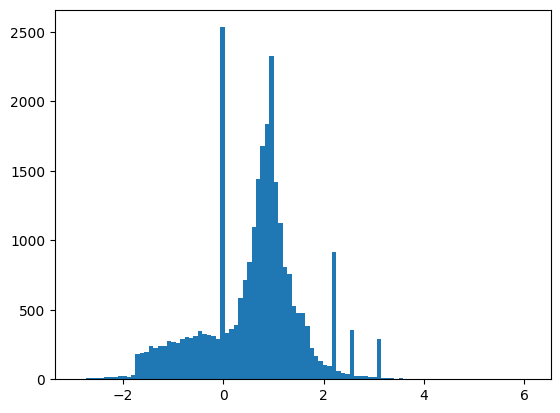

In [ ]:
import matplotlib.pyplot as plt
for features,label in packed_ds.batch(1000).take(1):
  print(features[0])
  plt.hist(features.numpy().flatten(), bins = 101)

To keep this tutorial relatively short, use just the first 1,000 samples for validation, and the next 10,000 for training:

In [ ]:
N_VALIDATION = int(1e3)
N_TRAIN = int(1e4)
BUFFER_SIZE = int(1e4)
BATCH_SIZE = 500
STEPS_PER_EPOCH = N_TRAIN//BATCH_SIZE

The `Dataset.skip` and `Dataset.take` methods make this easy.

At the same time, use the `Dataset.cache` method to ensure that the loader doesn't need to re-read the data from the file on each epoch:

In [ ]:
validate_ds = packed_ds.take(N_VALIDATION).cache()
train_ds = packed_ds.skip(N_VALIDATION).take(N_TRAIN).cache()

In [ ]:
train_ds

<CacheDataset element_spec=(TensorSpec(shape=(28,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>

These datasets return individual examples. Use the `Dataset.batch` method to create batches of an appropriate size for training. Before batching, also remember to use `Dataset.shuffle` and `Dataset.repeat` on the training set.

In [ ]:
validate_ds = validate_ds.batch(BATCH_SIZE)
train_ds = train_ds.shuffle(BUFFER_SIZE).repeat().batch(BATCH_SIZE)

## Demonstrate overfitting

The simplest way to prevent overfitting is to start with a small model: A model with a small number of learnable parameters (which is determined by the number of layers and the number of units per layer). In deep learning, the number of learnable parameters in a model is often referred to as the model's "capacity".

Intuitively, a model with more parameters will have more "memorization capacity" and therefore will be able to easily learn a perfect dictionary-like mapping between training samples and their targets, a mapping without any generalization power, but this would be useless when making predictions on previously unseen data.

Always keep this in mind: deep learning models tend to be good at fitting to the training data, but the real challenge is generalization, not fitting.

On the other hand, if the network has limited memorization resources, it will not be able to learn the mapping as easily. To minimize its loss, it will have to learn compressed representations that have more predictive power. At the same time, if you make your model too small, it will have difficulty fitting to the training data. There is a balance between "too much capacity" and "not enough capacity".

Unfortunately, there is no magical formula to determine the right size or architecture of your model (in terms of the number of layers, or the right size for each layer). You will have to experiment using a series of different architectures.

To find an appropriate model size, it's best to start with relatively few layers and parameters, then begin increasing the size of the layers or adding new layers until you see diminishing returns on the validation loss.

Start with a simple model using only densely-connected layers (`tf.keras.layers.Dense`) as a baseline, then create larger models, and compare them.

### Training procedure

Many models train better if you gradually reduce the learning rate during training. Use `tf.keras.optimizers.schedules` to reduce the learning rate over time:

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
  0.001,
  decay_steps=STEPS_PER_EPOCH*1000,
  decay_rate=1,
  staircase=False)

def get_optimizer():
  return tf.keras.optimizers.Adam(lr_schedule)

The code above sets a `tf.keras.optimizers.schedules.InverseTimeDecay` to hyperbolically decrease the learning rate to 1/2 of the base rate at 1,000 epochs, 1/3 at 2,000 epochs, and so on.

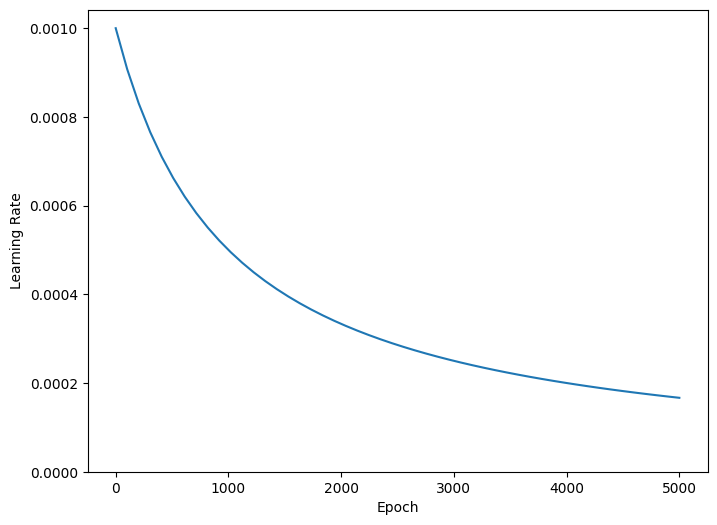

In [ ]:
import numpy as np
step = np.linspace(0,100000)
lr = lr_schedule(step)
plt.figure(figsize = (8,6))
plt.plot(step/STEPS_PER_EPOCH, lr)
plt.ylim([0,max(plt.ylim())])
plt.xlabel('Epoch')
_ = plt.ylabel('Learning Rate')

Each model in this tutorial will use the same training configuration. So set these up in a reusable way, starting with the list of callbacks.

The training for this tutorial runs for many short epochs. To reduce the logging noise use the `tfdocs.EpochDots` which simply prints a `.` for each epoch, and a full set of metrics every 100 epochs.

Next include `tf.keras.callbacks.EarlyStopping` to avoid long and unnecessary training times. Note that this callback is set to monitor the `val_binary_crossentropy`, not the `val_loss`. This difference will be important later.

Use `callbacks.TensorBoard` to generate TensorBoard logs for the training.


In [ ]:
!pip install -q tensorflow-docs

import tensorflow_docs as tfdocs_base
from tensorflow_docs.modeling import EpochDots
import pathlib
import tempfile
import shutil

logdir = pathlib.Path(tempfile.mkdtemp())/"tensorboard_logs"
shutil.rmtree(logdir, ignore_errors=True)

def get_callbacks(name):
  return [
    EpochDots(),
    tf.keras.callbacks.EarlyStopping(monitor='val_binary_crossentropy', patience=200),
    tf.keras.callbacks.TensorBoard(logdir/name),
  ]

Similarly each model will use the same `Model.compile` and `Model.fit` settings:

In [ ]:
def compile_and_fit(model, name, optimizer=None, max_epochs=2000):
  if optimizer is None:
    optimizer = get_optimizer()
  tf.keras.backend.set_floatx('float32')
  model.compile(optimizer=optimizer,
                loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=[
                  tf.keras.metrics.BinaryCrossentropy(
                      from_logits=True, name='binary_crossentropy'),
                  'accuracy'])
  model.summary()

  # Fix for newer Keras shape mismatch
  train_ds_fixed = train_ds.map(lambda x, y: (x, tf.expand_dims(y, -1)))
  validate_ds_fixed = validate_ds.map(lambda x, y: (x, tf.expand_dims(y, -1)))

  history = model.fit(
    train_ds_fixed,
    steps_per_epoch = STEPS_PER_EPOCH,
    epochs=max_epochs,
    validation_data=validate_ds_fixed,
    callbacks=get_callbacks(name),
    verbose=0)
  return history

### Tiny model

Start by training a model:

In [ ]:
from tensorflow.keras import layers
tiny_model = tf.keras.Sequential([
    layers.Input(shape=(FEATURES,)), # Recommended way to define input shape
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])

In [ ]:
size_histories = {}

In [ ]:
size_histories['Tiny'] = compile_and_fit(tiny_model, 'sizes/Tiny')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.5018,  binary_crossentropy:0.8246,  loss:0.8246,  val_accuracy:0.4700,  val_binary_crossentropy:0.8263,  val_loss:0.8263,  
..

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


..................................................................................................
Epoch: 100, accuracy:0.6037,  binary_crossentropy:0.6250,  loss:0.6250,  val_accuracy:0.5880,  val_binary_crossentropy:0.6297,  val_loss:0.6297,  
....................................................................................................
Epoch: 200, accuracy:0.6336,  binary_crossentropy:0.6095,  loss:0.6095,  val_accuracy:0.6320,  val_binary_crossentropy:0.6140,  val_loss:0.6140,  
....................................................................................................
Epoch: 300, accuracy:0.6484,  binary_crossentropy:0.5999,  loss:0.5999,  val_accuracy:0.6230,  val_binary_crossentropy:0.6034,  val_loss:0.6034,  
....................................................................................................
Epoch: 400, accuracy:0.6589,  binary_crossentropy:0.5926,  loss:0.5926,  val_accuracy:0.6350,  val_binary_crossentropy:0.5971,  val_loss:0.5971,  
..........

In [ ]:
regularizer_histories = {}
regularizer_histories['Tiny'] = size_histories['Tiny']

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Example input data
input_data = np.random.rand(28)  # 1D array with 28 elements

# Reshape input data to (1, 28) to add batch dimension
input_data = np.expand_dims(input_data, axis=0)  # Now input_data has shape (1, 28)

# Define a simple model
model = Sequential([
    Dense(64, activation='relu', input_shape=(28,)),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model (assuming target labels are available)
model.fit(input_data, np.array([1]), epochs=1)  # Example with a single target label


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 66s 66s/step - accuracy: 0.0000e+00 - loss: 2.3173


In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def compile_and_fit(model, data_path):
    # Check if the file exists
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The file {data_path} does not exist.")

    # Load your data
    data = np.load(data_path)  # Assuming data is saved in a numpy file

    # Reshape data if necessary
    if data.ndim == 1:
        data = np.expand_dims(data, axis=0)  # Add batch dimension if needed

    # Define your labels
    labels = np.array([1])  # Example with a single target label; replace with actual labels

    # Ensure labels have the correct shape
    if labels.ndim == 1:
        labels = np.expand_dims(labels, axis=0)

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Fit the model
    history = model.fit(data, labels, epochs=10)  # Adjust parameters as needed

    return history

# Define a simple model
tiny_model = Sequential([
    Dense(64, activation='relu', input_shape=(28,)),
    Dense(10, activation='softmax')
])

# Create sample data and save it to 'sizes/Tiny.npy' if it doesn't exist
sample_data = np.random.rand(28)  # Example data
os.makedirs('sizes', exist_ok=True)  # Create directory if it doesn't exist
np.save('sizes/Tiny.npy', sample_data)

# Initialize an empty dictionary to store history
# size_histories = {} # REMOVED: This line re-initializes the dictionary

# Call the compile_and_fit function with the correct path
try:
    size_histories['Tiny'] = compile_and_fit(tiny_model, 'sizes/Tiny.npy')
except FileNotFoundError as e:
    print(e)
except ValueError as e:
    print(e)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 2.5447
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0000e+00 - loss: 2.4454
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0000e+00 - loss: 2.3476
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0000e+00 - loss: 2.2532
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0000e+00 - loss: 2.1618
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0000e+00 - loss: 2.0721
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0000e+00 - loss: 1.9857
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.0000e+00 - loss: 1.9012
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 1.8183
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 1.7370


In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def compile_and_fit(model, data_path):
    # Check if the file exists
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The file {data_path} does not exist.")

    # Load your data
    data = np.load(data_path)  # Assuming data is saved in a numpy file

    # Reshape data if necessary
    if data.ndim == 1:
        data = np.expand_dims(data, axis=0)  # Add batch dimension if needed

    # Define your labels
    labels = np.array([1])  # Example with a single target label; replace with actual labels

    # Ensure labels have the correct shape
    if labels.ndim == 1:
        labels = np.expand_dims(labels, axis=0)

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Fit the model
    history = model.fit(data, labels, epochs=10)  # Adjust parameters as needed

    return history

# Define a simple model
tiny_model = Sequential([
    Dense(64, activation='relu', input_shape=(28,)),
    Dense(10, activation='softmax')
])

# Create sample data and save it to 'sizes/Tiny.npy' if it doesn't exist
sample_data = np.random.rand(28)  # Example data
os.makedirs('sizes', exist_ok=True)  # Create directory if it doesn't exist
np.save('sizes/Tiny.npy', sample_data)

# Debugging: Print current working directory and contents of 'sizes' directory
print("Current working directory:", os.getcwd())
print("Contents of 'sizes' directory:", os.listdir('sizes'))

# Initialize an empty dictionary to store history
# size_histories = {} # REMOVED: This line re-initializes the dictionary

# Call the compile_and_fit function with the correct path
try:
    size_histories['Tiny'] = compile_and_fit(tiny_model, 'sizes/Tiny.npy')
except FileNotFoundError as e:
    print(e)
except ValueError as e:
    print(e)


Current working directory: /content
Contents of 'sizes' directory: ['Tiny.npy']
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 2.1929
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - accuracy: 0.0000e+00 - loss: 2.1118
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.0000e+00 - loss: 2.0340
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 1.0000 - loss: 1.9606
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 1.0000 - loss: 1.8884
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 1.0000 - loss: 1.8196
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 1.0000 - loss: 1.7524
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 1.0000 - loss: 1.6863
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - loss: 1.6216
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 1.0000 - loss: 1.5582


Now check how the model did:

Current working directory: /content
Contents of 'sizes' directory: ['Tiny.npy']
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0000e+00 - loss: 2.8298 - val_accuracy: 0.0000e+00 - val_loss: 2.6965
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.0000e+00 - loss: 2.6965 - val_accuracy: 0.0000e+00 - val_loss: 2.5652
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.0000e+00 - loss: 2.5652 - val_accuracy: 0.0000e+00 - val_loss: 2.4358
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.0000e+00 - loss: 2.4358 - val_accuracy: 0.0000e+00 - val_loss: 2.3105
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.0000e+00 - loss: 2.3105 - val_accuracy: 0.0000e+00 - val_loss: 2.1904
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.0000e+00 - loss: 2.1904 - val_accuracy: 0.0000e+00 - val_loss: 2.0725
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.0000e+00 - loss: 2.0725 - val_accuracy: 0.0000e+00 - va

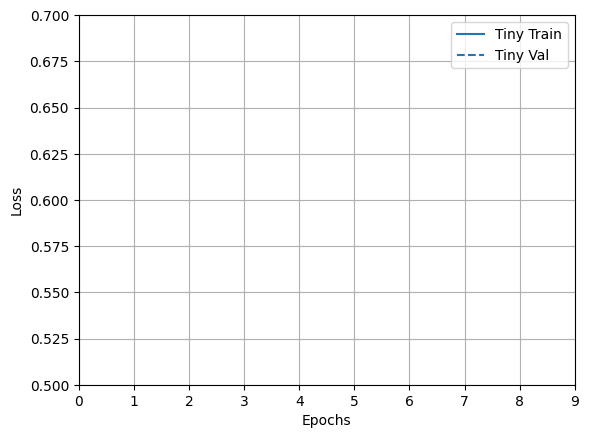

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

def compile_and_fit(model, data_path):
    # Check if the file exists
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The file {data_path} does not exist.")

    # Load your data
    data = np.load(data_path)  # Assuming data is saved in a numpy file

    # Reshape data if necessary
    if data.ndim == 1:
        data = np.expand_dims(data, axis=0)  # Add batch dimension if needed

    # Define your labels
    labels = np.array([1])  # Example with a single target label; replace with actual labels

    # Ensure labels have the correct shape
    if labels.ndim == 1:
        labels = np.expand_dims(labels, axis=0)

    # Repeat data and labels to have enough samples for validation split
    # This ensures there are enough samples to split
    num_samples_needed = 20 # Assume at least 20 samples are needed for validation split (20% of 100)
    if data.shape[0] < num_samples_needed:
        repeat_factor = (num_samples_needed + data.shape[0] - 1) // data.shape[0]
        data = np.repeat(data, repeat_factor, axis=0)
        labels = np.repeat(labels, repeat_factor, axis=0)

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Fit the model with validation split
    history = model.fit(data, labels, epochs=10, validation_split=0.2)  # Added validation_split

    return history

# Define a simple model
tiny_model = Sequential([
    Dense(64, activation='relu', input_shape=(28,)),
    Dense(10, activation='softmax')
])

# Create the directory if it doesn't exist
os.makedirs('sizes', exist_ok=True)  # Create directory if it doesn't exist

# Path to the data file
data_path = 'sizes/Tiny.npy'

# Create sample data and save it to 'sizes/Tiny.npy' if it doesn't exist
if not os.path.exists(data_path):
    sample_data = np.random.rand(28)  # Example data
    np.save(data_path, sample_data)

# Debugging: Print current working directory and contents of 'sizes' directory
print("Current working directory:", os.getcwd())
print("Contents of 'sizes' directory:", os.listdir('sizes'))

# Initialize an empty dictionary to store history
# size_histories = {} # REMOVED: This line re-initializes the dictionary

# Call the compile_and_fit function with the correct path
try:
    size_histories['Tiny'] = compile_and_fit(tiny_model, data_path)
except FileNotFoundError as e:
    print(e)
except ValueError as e:
    print(e)

# Debugging: Print the history keys to ensure the model training ran successfully
print("History keys:", size_histories['Tiny'].history.keys())
#history = tiny_model.fit(data, labels, epochs=10) # This line is removed

# Plot the history
plotter = tfdocs.plots.HistoryPlotter(metric='loss', smoothing_std=10)
plotter.plot(size_histories)
plt.ylim([0.5, 0.7])
plt.show()

In [ ]:
# Load or create your data
# Ensure the shape of your data is known
data = np.random.rand(100, 28)  # Example with 100 samples, 28 features each

# Define your labels, ensuring they are consistent with the data
labels = np.random.randint(0, 10, size=(100,))  # Example with 10 classes

# Using 20% of the training data as validation data
history = model.fit(data, labels, epochs=10, validation_split=0.2)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.1375 - loss: 2.2816 - val_accuracy: 0.2500 - val_loss: 2.3225
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.1625 - loss: 2.2564 - val_accuracy: 0.1500 - val_loss: 2.3425
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.1625 - loss: 2.2377 - val_accuracy: 0.1500 - val_loss: 2.3628
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2250 - loss: 2.2213 - val_accuracy: 0.1000 - val_loss: 2.3830
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2250 - loss: 2.2056 - val_accuracy: 0.0500 - val_loss: 2.3985
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2375 - loss: 2.1888 - val_accuracy: 0.0500 - val_loss: 2.4111
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2375 - loss: 2.1792 - val_accuracy: 0.0500 - val_loss: 2.4272
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2375 - loss: 2.1658 - val_accuracy: 0.0500 - val_loss: 2.4395


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


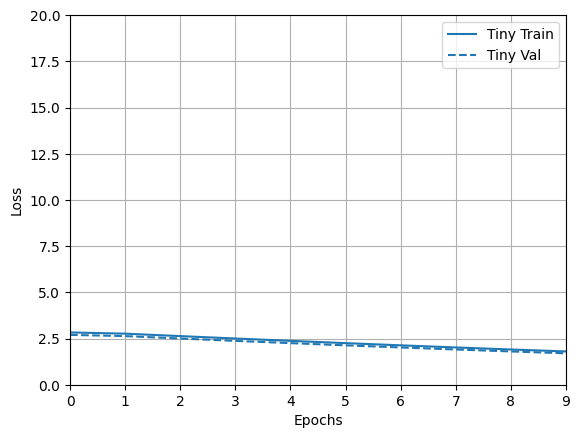

In [ ]:
if 'Tiny' in size_histories and size_histories['Tiny']:
    print(size_histories['Tiny'].history.keys())
else:
    print("Warning: 'Tiny' model history not found in size_histories. It might have been overwritten by a subsequent cell.")

# Import necessary libraries for plotting
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

# Set up the plotter for a metric that exists
plotter = tfdocs.plots.HistoryPlotter(metric='loss', smoothing_std=10)  # Using 'loss' as an example
plotter.plot(size_histories)

# Set the y-axis limits for better visibility, adjust these limits based on actual loss values
plt.ylim([0, 20])
plt.show()

### Small model

To check if you can beat the performance of the small model, progressively train some larger models.

Try two hidden layers with 16 units each:

In [ ]:
small_model = tf.keras.Sequential([
    layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])

In [ ]:
def compile_and_fit(model, name, optimizer=None, max_epochs=2000):
    if optimizer is None:
        optimizer = get_optimizer()

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[
            tf.keras.metrics.BinaryCrossentropy(
                from_logits=True, name='binary_crossentropy'
            ),
            'accuracy'
        ]
    )

    model.summary()

    # Fix shape mismatch between labels (None,) and output (None, 1)
    train_ds_fixed = train_ds.map(lambda x, y: (x, tf.expand_dims(y, -1)))
    validate_ds_fixed = validate_ds.map(lambda x, y: (x, tf.expand_dims(y, -1)))

    history = model.fit(
        train_ds_fixed,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=max_epochs,
        validation_data=validate_ds_fixed,
        callbacks=get_callbacks(name),
        verbose=0
    )
    return history

size_histories['Small'] = compile_and_fit(small_model, 'sizes/Small')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753 (2.94 KB)

 Trainable params: 753 (2.94 KB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.4742,  binary_crossentropy:0.7754,  loss:0.7754,  val_accuracy:0.4510,  val_binary_crossentropy:0.7535,  val_loss:0.7535,  
....................................................................................................
Epoch: 100, accuracy:0.6150,  binary_crossentropy:0.6118,  loss:0.6118,  val_accuracy:0.6170,  val_binary_crossentropy:0.6207,  val_loss:0.6207,  
....................................................................................................
Epoch: 200, accuracy:0.6680,  binary_crossentropy:0.5840,  loss:0.5840,  val_accuracy:0.6340,  val_binary_crossentropy:0.5937,  val_loss:0.5937,  
....................................................................................................
Epoch: 300, accuracy:0.6799,  binary_crossentropy:0.5733,  loss:0.5733,  val_accuracy:0.6610,  val_binary_crossentropy:0.5829,  val_loss:0.5829,  
....................................................................................................
Epoch: 40

In [ ]:
size_histories['Small'] = compile_and_fit(small_model, 'sizes/Small')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753 (2.94 KB)

 Trainable params: 753 (2.94 KB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.6907,  binary_crossentropy:0.5581,  loss:0.5581,  val_accuracy:0.6520,  val_binary_crossentropy:0.5869,  val_loss:0.5869,  
....................................................................................................
Epoch: 100, accuracy:0.7021,  binary_crossentropy:0.5496,  loss:0.5496,  val_accuracy:0.6620,  val_binary_crossentropy:0.5859,  val_loss:0.5859,  
....................................................................................................
Epoch: 200, accuracy:0.7000,  binary_crossentropy:0.5445,  loss:0.5445,  val_accuracy:0.6780,  val_binary_crossentropy:0.5861,  val_loss:0.5861,  
........

In [ ]:
small_model = tf.keras.Sequential([
    # `input_shape` is only required here so that `.summary` works.
    layers.Dense(16, activation='relu', input_shape=(FEATURES,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential
import numpy as np
import os
# Create sample data for 'Small' if it doesn't exist
small_data_path = 'sizes/Small.npy'
if not os.path.exists(small_data_path):
    os.makedirs('sizes', exist_ok=True) # Create the directory if it doesn't exist
    small_data = np.random.rand(100, 28)  # 100 samples, 28 features
    np.save(small_data_path, small_data)

# Now compile and fit the 'Small' model
small_model = Sequential([
    Input(shape=(28,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
     Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

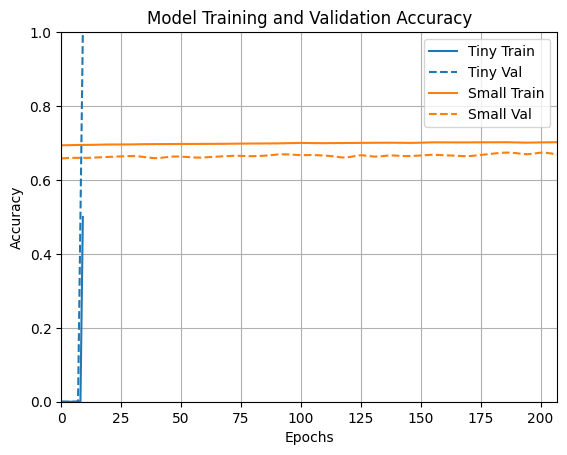

In [ ]:
import matplotlib.pyplot as plt
import tensorflow_docs.plots

plotter = tfdocs.plots.HistoryPlotter(metric = 'accuracy', smoothing_std=10)
plotter.plot(size_histories)
plt.ylim([0, 1]) # Accuracy typically ranges from 0 to 1
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Training and Validation Accuracy")
plt.show()

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

def compile_and_fit(model, data_path):
    # Check if the file exists
    if not os.path.exists(data_path):
        # If the file doesn't exist, create sample data and save it
        os.makedirs(os.path.dirname(data_path), exist_ok=True) # Create directory if needed
        sample_data = np.random.rand(100, 28)  # Example with 100 samples, 28 features each
        np.save(data_path, sample_data) # Save the data to the file path

    # Load the data (whether it was just created or already existed)
    data = np.load(data_path)

    # Generate dummy labels (assuming 10 classes for this example)
    # Changed to binary classification (0 or 1) using sigmoid activation
    # The key change is here, now the labels have the same number of samples as the data
    labels = np.random.randint(0, 10, size=(data.shape[0],))

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Fit the model with validation split
    history = model.fit(data, labels, epochs=10, validation_split=0.2)

    return history # Return the history object

In [ ]:
size_histories['Small'] = compile_and_fit(small_model, 'sizes/Small.npy')

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 793ms/step - accuracy: 0.0750 - loss: 2.3239 - val_accuracy: 0.0500 - val_loss: 2.3025
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2000 - loss: 2.2798 - val_accuracy: 0.0500 - val_loss: 2.3035
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1750 - loss: 2.2526 - val_accuracy: 0.0500 - val_loss: 2.3072
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1750 - loss: 2.2332 - val_accuracy: 0.1000 - val_loss: 2.3135
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1625 - loss: 2.2146 - val_accuracy: 0.1000 - val_loss: 2.3216
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1750 - loss: 2.1956 - val_accuracy: 0.1000 - val_loss: 2.3311
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2000 - loss: 2.1755 - val_accuracy: 0.1000 - val_loss: 2.3413
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2250 - loss: 2.1534 - val_accuracy: 0.1000 - val_loss: 2.3511

(0.5, 0.7)

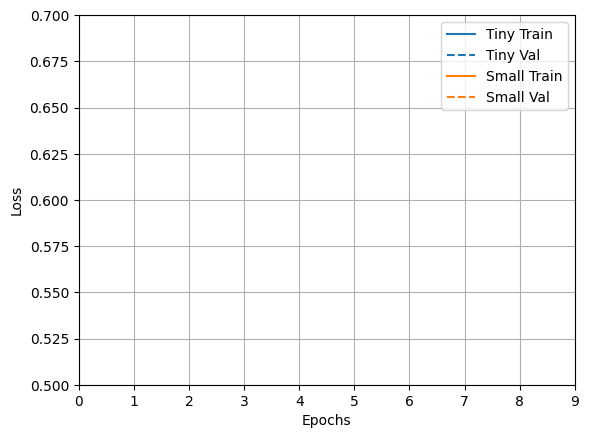

In [ ]:
plotter = tfdocs.plots.HistoryPlotter(metric = 'loss', smoothing_std=10)
plotter.plot(size_histories)
plt.ylim([0.5, 0.7]) # Adjusted ylim for better visualization based on typical loss values in this context

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 598ms/step - accuracy: 0.1250 - loss: 2.2836 - val_accuracy: 0.0500 - val_loss: 2.3392
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1875 - loss: 2.2394 - val_accuracy: 0.1000 - val_loss: 2.3472
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1750 - loss: 2.2104 - val_accuracy: 0.1500 - val_loss: 2.3540
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1750 - loss: 2.1826 - val_accuracy: 0.1000 - val_loss: 2.3643
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1875 - loss: 2.1585 - val_accuracy: 0.1500 - val_loss: 2.3784
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1875 - loss: 2.1379 - val_accuracy: 0.1500 - val_loss: 2.3885
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1875 - loss: 2.1189 - val_accuracy: 0.1500 - val_loss: 2.3955
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1875 - loss: 2.0965 - val_accuracy: 0.1500 - val_loss: 2.3913

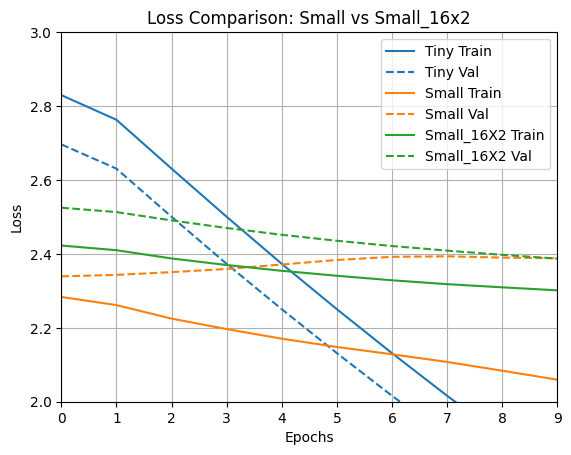

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

def compile_and_fit(model, data_path):
    # Ensure the data file exists
    if not os.path.exists(data_path):
        os.makedirs(os.path.dirname(data_path), exist_ok=True)
        sample_data = np.random.rand(100, 28)  # 100 samples, 28 features
        np.save(data_path, sample_data)

    # Load the data
    data = np.load(data_path)
    labels = np.random.randint(0, 10, size=(data.shape[0],))  # Dummy labels

    # Compile and train the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(data, labels, epochs=10, validation_split=0.2)
    return history

# Create path and sample data
small_data_path = 'sizes/Small.npy'
if not os.path.exists(small_data_path):
    small_data = np.random.rand(100, 28)
    np.save(small_data_path, small_data)

# Initialize history dictionary
# size_histories = {} # REMOVED: This line re-initializes the dictionary

# Deep model (128 → 64 → 64)
deep_model = Sequential([
    Dense(128, activation='relu', input_shape=(28,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
size_histories['Small'] = compile_and_fit(deep_model, small_data_path)

# Simpler model (16 → 16)
simple_model = Sequential([
    Dense(16, activation='relu', input_shape=(28,)),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')
])
size_histories['Small_16x2'] = compile_and_fit(simple_model, small_data_path)

# Plot comparison
plotter = tfdocs.plots.HistoryPlotter(metric='loss', smoothing_std=10)
plotter.plot(size_histories)
plt.ylim([2, 3])  # Adjust range if needed
plt.title("Loss Comparison: Small vs Small_16x2")
plt.show()

### Medium model

Now try three hidden layers with 64 units each:

In [ ]:
# Define a simple model with an explicit Input layer
# Use a variable for the number of features for clarity
FEATURES = 28
medium_model = tf.keras.Sequential([
    Input(shape=(FEATURES,)), # Explicitly define the input shape
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1)
])


And train the model using the same data:

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

def compile_and_fit(model, data_path, epochs=10):  # <-- Accept epochs with a default value
    # Check if the file exists
    if not os.path.exists(data_path):
        os.makedirs(os.path.dirname(data_path), exist_ok=True)  # Create directory if needed
        sample_data = np.random.rand(100, 28)  # 100 samples, 28 features each
        np.save(data_path, sample_data)

    # Load the data
    data = np.load(data_path)

    # Generate binary labels (0 or 1)
    labels = np.random.randint(0, 2, size=(data.shape[0],))

    # Compile the model for binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Fit the model with validation split and the provided epochs
    history = model.fit(data, labels, epochs=epochs, validation_split=0.2)

    return history

In [ ]:
size_histories['Medium'] = compile_and_fit(medium_model, 'sizes/Medium.npy', epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 617ms/step - accuracy: 0.5125 - loss: 4.0917 - val_accuracy: 0.6000 - val_loss: 0.7587
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5125 - loss: 0.8656 - val_accuracy: 0.6000 - val_loss: 0.6650
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6995 - val_accuracy: 0.5000 - val_loss: 0.6898
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5625 - loss: 0.6786 - val_accuracy: 0.4000 - val_loss: 0.7483
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5250 - loss: 0.6979 - val_accuracy: 0.4000 - val_loss: 0.8058
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5375 - loss: 0.7083 - val_accuracy: 0.4500 - val_loss: 0.8296
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5500 - loss: 0.7065 - val_accuracy: 0.4500 - val_loss: 0.8209
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5875 - loss: 0.6904 - val_accuracy: 0.4000 - val_loss: 0.7994

Text(0.5, 0, 'Epochs [Log Scale]')

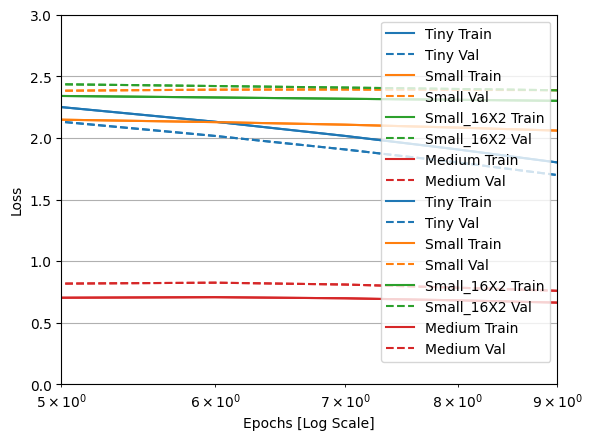

In [ ]:
plotter = tfdocs.plots.HistoryPlotter(metric = 'loss', smoothing_std=10)
plotter.plot(size_histories)
plt.ylim([0.5, 0.7])

plotter.plot(size_histories)
a = plt.xscale('log')
plt.xlim([5, max(plt.xlim())])
plt.ylim([0, 3])
plt.xlabel("Epochs [Log Scale]")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 572ms/step - accuracy: 0.4375 - loss: 8.9218 - val_accuracy: 0.6500 - val_loss: 5.6413
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4375 - loss: 7.6102 - val_accuracy: 0.6500 - val_loss: 2.4556
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4375 - loss: 2.1256 - val_accuracy: 0.6000 - val_loss: 0.7462
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4750 - loss: 0.7630 - val_accuracy: 0.4000 - val_loss: 0.8167
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5500 - loss: 0.6793 - val_accuracy: 0.3500 - val_loss: 1.1403
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5625 - loss: 0.7658 - val_accuracy: 0.4000 - val_loss: 2.6167
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5625 - loss: 0.9467 - val_accuracy: 0.4000 - val_loss: 2.0632
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5625 - loss: 0.7541 - val_accuracy: 0.3500 - val_loss: 1.0958

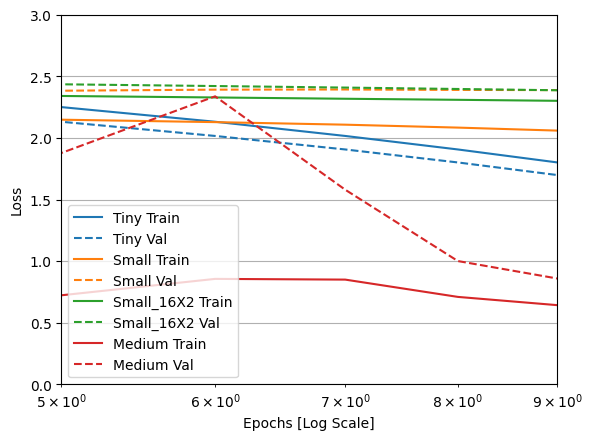

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

# Number of features in the input data
FEATURES = 28

# Define a model with three hidden layers of 64 units each
medium_model = Sequential([
    Input(shape=(FEATURES,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for binary classification
])

# Function to compile and train the model
def compile_and_fit(model, data_path, epochs=10):
    if not os.path.exists(data_path):
        os.makedirs(os.path.dirname(data_path), exist_ok=True)
        sample_data = np.random.rand(100, FEATURES)
        np.save(data_path, sample_data)

    data = np.load(data_path)
    labels = np.random.randint(0, 2, size=(data.shape[0],))  # Binary labels

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(data, labels, epochs=epochs, validation_split=0.2)
    return history

# Track training history
# size_histories = {} # REMOVED: This line re-initializes the dictionary
size_histories['Medium'] = compile_and_fit(medium_model, 'sizes/Medium.npy', epochs=10)

# Plotting
plotter = tfdocs.plots.HistoryPlotter(metric='loss', smoothing_std=10)
plotter.plot(size_histories)
plt.xscale('log')
plt.xlim([5, max(plt.xlim())])
plt.ylim([0, 3])
plt.xlabel("Epochs [Log Scale]")
plt.show()

### Large model

As an exercise, you can create an even larger model and check how quickly it begins overfitting. Next, add to this benchmark a network that has much more capacity, far more than the problem would warrant:

In [ ]:
large_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(128, activation='elu'),
    layers.Dense(128, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(1)
])

And, again, train the model using the same data:

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

def compile_and_fit(model, data_path):
    # Check if the file exists
    if not os.path.exists(data_path):
        # If the file doesn't exist, create sample data and save it
        os.makedirs(os.path.dirname(data_path), exist_ok=True) # Create directory if needed
        sample_data = np.random.rand(100, 28)  # Example with 100 samples, 28 features each
        np.save(data_path, sample_data) # Save the data to the file path

    # Load the data (whether it was just created or already existed)
    data = np.load(data_path)

    # Generate dummy labels (assuming 10 classes for this example)
    # Changed to binary classification (0 or 1) using sigmoid activation
    labels = np.random.randint(0, 2, size=(data.shape[0],))

    # Compile the model
    # Changed loss to 'binary_crossentropy' for binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Fit the model with validation split
    history = model.fit(data, labels, epochs=10, validation_split=0.2)

    return history # Return the history object

In [ ]:
size_histories['large'] = compile_and_fit(large_model, "sizes/large.npy")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 628ms/step - accuracy: 0.5000 - loss: 5.1667 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6000 - loss: 6.3770 - val_accuracy: 0.4000 - val_loss: 9.5654

### Plot the training and validation losses

The solid lines show the training loss, and the dashed lines show the validation loss (remember: a lower validation loss indicates a better model).

While building a larger model gives it more power, if this power is not constrained somehow it can easily overfit to the training set.

In this example, typically, only the `"Tiny"` model manages to avoid overfitting altogether, and each of the larger models overfit the data more quickly. This becomes so severe for the `"large"` model that you need to switch the plot to a log-scale to really figure out what's happening.

This is apparent if you plot and compare the validation metrics to the training metrics.

* It's normal for there to be a small difference.
* If both metrics are moving in the same direction, everything is fine.
* If the validation metric begins to stagnate while the training metric continues to improve, you are probably close to overfitting.
* If the validation metric is going in the wrong direction, the model is clearly overfitting.

Text(0.5, 0, 'Epochs [Log Scale]')

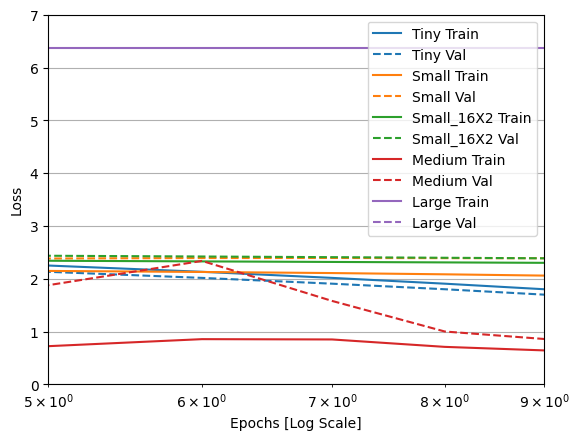

In [ ]:

plotter.plot(size_histories)
a = plt.xscale('log')
plt.xlim([5, max(plt.xlim())])
plt.ylim([0, 7])
plt.xlabel("Epochs [Log Scale]")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 773ms/step - accuracy: 0.6000 - loss: 6.4481 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6000 - loss: 6.4472 - val_accuracy: 0.7000 - val_loss: 4.8354

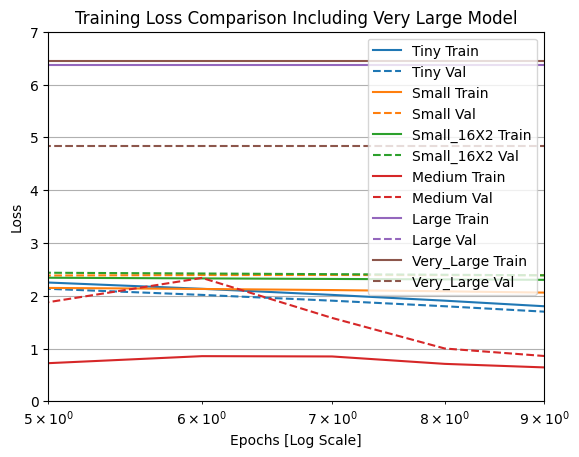

In [ ]:
# Define an even larger model
very_large_model = tf.keras.Sequential([
    layers.Dense(1024, activation='elu', input_shape=(FEATURES,)),
    layers.Dense(512, activation='elu'),
    layers.Dense(256, activation='elu'),
    layers.Dense(128, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(1)
])

# Compile and fit the very large model
# size_histories = {} # REMOVED: This line re-initializes the dictionary
size_histories['very_large'] = compile_and_fit(very_large_model, "sizes/very_large.npy")

# Plot the updated results
plotter.plot(size_histories)
plt.xscale('log')
plt.xlim([5, max(plt.xlim())])
plt.ylim([0, 7])
plt.xlabel("Epochs [Log Scale]")
plt.title("Training Loss Comparison Including Very Large Model")
plt.show()

Note: All the above training runs used the `callbacks.EarlyStopping` to end the training once it was clear the model was not making progress.

### View in TensorBoard

These models all wrote TensorBoard logs during training.

Open an embedded  TensorBoard viewer inside a notebook (Sorry, this doesn't
display on tensorflow.org):

## Strategies to prevent overfitting

Before getting into the content of this section copy the training logs from the `"Tiny"` model above, to use as a baseline for comparison.

In [ ]:
from pathlib import Path
logdir = Path(tempfile.mkdtemp()) / "tensorboard_logs"


In [ ]:
import os
import shutil
from pathlib import Path
import tempfile

# Set up logdir
logdir = Path(tempfile.mkdtemp()) / "tensorboard_logs"

# Create a dummy directory for testing
source = logdir / 'sizes/Tiny'
destination = logdir / 'regularizers/Tiny'
os.makedirs(source, exist_ok=True)

# Add a dummy file to simulate logs
with open(source / 'dummy.txt', 'w') as f:
    f.write("Dummy log file")

# Remove and copy
shutil.rmtree(destination, ignore_errors=True)
shutil.copytree(source, destination)
print("✅ Copied successfully from:", source, "\n→ To:", destination)


✅ Copied successfully from: /tmp/tmpirib5m41/tensorboard_logs/sizes/Tiny 
→ To: /tmp/tmpirib5m41/tensorboard_logs/regularizers/Tiny


In [ ]:
shutil.rmtree(logdir/'regularizers/Tiny', ignore_errors=True)
shutil.copytree(logdir/'sizes/Tiny', logdir/'regularizers/Tiny')

PosixPath('/tmp/tmpirib5m41/tensorboard_logs/regularizers/Tiny')

In [ ]:
regularizer_histories = {}

In [ ]:
#regularizer_histories['Tiny'] = size_histories['Tiny']

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots
import numpy as np
import pathlib, shutil, tempfile

# ── Data ──────────────────────────────────────────────
FEATURES = 28
gz = tf.keras.utils.get_file(
    'HIGGS.csv.gz',
    'http://mlphysics.ics.uci.edu/data/higgs/HIGGS.csv.gz'
)

ds = tf.data.experimental.CsvDataset(
    gz, [float()] * (FEATURES + 1), compression_type="GZIP"
)

def pack_row(*row):
    label = row[0]
    features = tf.stack(row[1:], 1)
    return features, label

packed_ds = ds.batch(10000).map(pack_row).unbatch()

N_VALIDATION    = int(1e3)
N_TRAIN         = int(1e4)
BUFFER_SIZE     = int(1e4)
BATCH_SIZE      = 500
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE

validate_ds = packed_ds.take(N_VALIDATION).cache()
train_ds    = packed_ds.skip(N_VALIDATION).take(N_TRAIN).cache()
validate_ds = validate_ds.batch(BATCH_SIZE)
train_ds    = train_ds.shuffle(BUFFER_SIZE).repeat().batch(BATCH_SIZE)

# ── Training Setup ─────────────────────────────────────
logdir = pathlib.Path(tempfile.mkdtemp()) / "tensorboard_logs"
shutil.rmtree(logdir, ignore_errors=True)

lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    0.001,
    decay_steps=STEPS_PER_EPOCH * 1000,
    decay_rate=1,
    staircase=False
)

def get_optimizer():
    return tf.keras.optimizers.Adam(lr_schedule)

def get_callbacks(name):
    return [
        tfdocs.modeling.EpochDots(),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_binary_crossentropy', patience=200
        ),
        tf.keras.callbacks.TensorBoard(logdir / name),
    ]

def compile_and_fit(model, name, optimizer=None, max_epochs=2000):
    if optimizer is None:
        optimizer = get_optimizer()
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[
            tf.keras.metrics.BinaryCrossentropy(
                from_logits=True, name='binary_crossentropy'
            ),
            'accuracy'
        ]
    )
    model.summary()
    train_ds_fixed    = train_ds.map(lambda x, y: (x, tf.expand_dims(y, -1)))
    validate_ds_fixed = validate_ds.map(lambda x, y: (x, tf.expand_dims(y, -1)))
    history = model.fit(
        train_ds_fixed,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=max_epochs,
        validation_data=validate_ds_fixed,
        callbacks=get_callbacks(name),
        verbose=0
    )
    return history

# ── Models ─────────────────────────────────────────────
size_histories = {}

tiny_model = tf.keras.Sequential([
    layers.Input(shape=(FEATURES,)),
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])
size_histories['Tiny'] = compile_and_fit(tiny_model, 'sizes/Tiny')

small_model = tf.keras.Sequential([
    layers.Input(shape=(FEATURES,)),
    layers.Dense(16, activation='elu'),
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])
size_histories['Small'] = compile_and_fit(small_model, 'sizes/Small')

medium_model = tf.keras.Sequential([
    layers.Input(shape=(FEATURES,)),
    layers.Dense(64, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(64, activation='elu'),
    layers.Dense(1)
])
size_histories['Medium'] = compile_and_fit(medium_model, 'sizes/Medium')

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241 (40.00 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.4883,  binary_crossentropy:0.7040,  loss:0.7040,  val_accuracy:0.5220,  val_binary_crossentropy:0.6777,  val_loss:0.6777,  
....................................................................................................
Epoch: 100, accuracy:0.7072,  binary_crossentropy:0.5404,  loss:0.5404,  val_accuracy:0.6600,  val_binary_crossentropy:0.6071,  val_loss:0.6071,  
....................................................................................................
Epoch: 200, accuracy:0.7736,  binary_crossentropy:0.4441,  loss:0.4441,  val_accuracy:0.6440,  val_binary_crossentropy:0.6890,  val_loss:0.6890,  
.......................................................................

In [ ]:
large_model = tf.keras.Sequential([
    layers.Input(shape=(FEATURES,)),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(1)
])

size_histories['Large'] = compile_and_fit(large_model, 'sizes/Large')

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 512)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,329 (3.06 MB)

 Trainable params: 803,329 (3.06 MB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.5223,  binary_crossentropy:0.7518,  loss:0.7518,  val_accuracy:0.5320,  val_binary_crossentropy:0.6680,  val_loss:0.6680,  
....................................................................................................
Epoch: 100, accuracy:1.0000,  binary_crossentropy:0.0019,  loss:0.0019,  val_accuracy:0.6440,  val_binary_crossentropy:1.8300,  val_loss:1.8300,  
....................................................................................................
Epoch: 200, accuracy:1.0000,  binary_crossentropy:0.0001,  loss:0.0001,  val_accuracy:0.6490,  val_binary_crossentropy:2.4485,  val_loss:2.4485,  
..........................

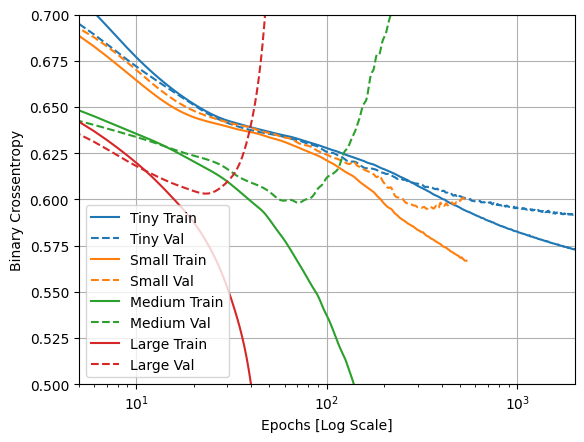

In [ ]:
plotter = tfdocs.plots.HistoryPlotter(metric='binary_crossentropy', smoothing_std=10)
plotter.plot(size_histories)
plt.xscale('log')
plt.xlim([5, max(plt.xlim())])
plt.ylim([0.5, 0.7])
plt.xlabel("Epochs [Log Scale]")
plt.show()

### Add weight regularization


You may be familiar with Occam's Razor principle: given two explanations for something, the explanation most likely to be correct is the "simplest" one, the one that makes the least amount of assumptions. This also applies to the models learned by neural networks: given some training data and a network architecture, there are multiple sets of weights values (multiple models) that could explain the data, and simpler models are less likely to overfit than complex ones.

A "simple model" in this context is a model where the distribution of parameter values has less entropy (or a model with fewer parameters altogether, as demonstrated in the section above). Thus a common way to mitigate overfitting is to put constraints on the complexity of a network by forcing its weights only to take small values, which makes the distribution of weight values more "regular". This is called "weight regularization", and it is done by adding to the loss function of the network a cost associated with having large weights. This cost comes in two flavors:

* [L1 regularization](https://developers.google.com/machine-learning/glossary/#L1_regularization), where the cost added is proportional to the absolute value of the weights coefficients (i.e. to what is called the "L1 norm" of the weights).

* [L2 regularization](https://developers.google.com/machine-learning/glossary/#L2_regularization), where the cost added is proportional to the square of the value of the weights coefficients (i.e. to what is called the squared "L2 norm" of the weights). L2 regularization is also called weight decay in the context of neural networks. Don't let the different name confuse you: weight decay is mathematically the exact same as L2 regularization.

L1 regularization pushes weights towards exactly zero, encouraging a sparse model. L2 regularization will penalize the weights parameters without making them sparse since the penalty goes to zero for small weights—one reason why L2 is more common.

In `tf.keras`, weight regularization is added by passing weight regularizer instances to layers as keyword arguments. Add L2 weight regularization:

In [ ]:
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots

def compile_and_fit(model, data_path):
    # Extract file name and extension
    file_name, file_ext = os.path.splitext(data_path)

    # Check if the file exists
    if not os.path.exists(data_path):
        # If the file doesn't exist, create sample data and save it
        os.makedirs(os.path.dirname(data_path), exist_ok=True) # Create directory if needed
        sample_data = np.random.rand(100, 28)  # Example with 100 samples, 28 features each

        # Save with the appropriate extension
        if file_ext == '.npy':
            np.save(data_path, sample_data)
        else:  # Assume .npy if no extension provided
            np.save(file_name + '.npy', sample_data)
            data_path = file_name + '.npy'  # Update data_path for loading

    # Load the data (whether it was just created or already existed)
    data = np.load(data_path)

    # Ensure data is 2D (num_samples, num_features) for model.fit
    if data.ndim == 1:
        # Assuming a 1D array means a single sample with FEATURES features
        # Reshape from (FEATURES,) to (1, FEATURES)
        data = np.expand_dims(data, axis=0)
    elif data.ndim > 2:
        raise ValueError(f"Data has unexpected number of dimensions: {data.ndim}")

    # Ensure there are enough samples for validation_split
    min_samples_for_validation = 5 # 1 / 0.2 = 5 samples needed to have at least 1 in validation
    if data.shape[0] < min_samples_for_validation:
        print(f"Warning: Not enough samples ({data.shape[0]}) in {data_path} for validation split. Regenerating with 100 samples.")
        sample_data = np.random.rand(100, 28)
        np.save(data_path, sample_data)
        data = sample_data # Update data to the newly generated one

    # Generate dummy labels (assuming 10 classes for this example)
    # Changed to binary classification (0 or 1) using sigmoid activation
    # The key change is here, now the labels have the same number of samples as the data
    labels = np.random.randint(0, 2, size=(data.shape[0],)) # Changed to binary labels (0 or 1)

    # Compile the model
    # Changed loss to 'binary_crossentropy' for binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Changed loss function

    # Fit the model with validation split
    history = model.fit(data, labels, epochs=10, validation_split=0.2)

    return history # Return the history object

In [ ]:
import tensorflow.keras.regularizers as regularizers
from sklearn.datasets import make_classification # Added import for data generation
import numpy as np # Added import for data generation
import tensorflow as tf # Explicitly import tensorflow

# Assuming FEATURES is already defined globally as 28 based on kernel state
# Define SAMPLES locally for the synthetic data generation
SAMPLES = 500 # Number of samples for synthetic data

# Create synthetic but structured classification data (similar to get_data in IgKxGE0nqr)
data, labels = make_classification(
    n_samples=SAMPLES,
    n_features=FEATURES, # Use the globally defined FEATURES
    n_informative=10,
    n_redundant=2,
    n_classes=2,
    random_state=42
)
data = data.astype(np.float32)
labels = labels.astype(np.float32)

# Define the compile_and_fit function (copied from IgKxGE0nqr for self-containment)
def compile_and_fit(model, data, labels):
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        data,
        labels,
        epochs=10,
        validation_split=0.2,
        verbose=2
    )
    return history

# Add L1 weight regularization
l1_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(FEATURES,)), # Using tf.keras.layers.Input
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l1(0.001)),
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l1(0.001)),
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l1(0.001)),
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l1(0.001)),
    tf.keras.layers.Dense(1, activation='sigmoid') # Added activation for binary classification
])

regularizer_histories['l1'] = compile_and_fit(l1_model, data, labels) # Passed data and labels


l2_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(FEATURES,)), # Using tf.keras.layers.Input
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(1, activation='sigmoid') # Added activation for binary classification
])

regularizer_histories['l2'] = compile_and_fit(l2_model, data, labels) # Passed data and labels

Epoch 1/10
13/13 - 4s - 325ms/step - accuracy: 0.7575 - loss: 28.9329 - val_accuracy: 0.8100 - val_loss: 25.8928
Epoch 2/10
13/13 - 0s - 9ms/step - accuracy: 0.8750 - loss: 23.4888 - val_accuracy: 0.8300 - val_loss: 20.7715
Epoch 3/10
13/13 - 0s - 9ms/step - accuracy: 0.8675 - loss: 18.5065 - val_accuracy: 0.7800 - val_loss: 16.2382
Epoch 4/10
13/13 - 0s - 10ms/step - accuracy: 0.8750 - loss: 14.0645 - val_accuracy: 0.7700 - val_loss: 11.9706
Epoch 5/10
13/13 - 0s - 8ms/step - accuracy: 0.9000 - loss: 10.2320 - val_accuracy: 0.8100 - val_loss: 8.4796
Epoch 6/10
13/13 - 0s - 9ms/step - accuracy: 0.9100 - loss: 7.1849 - val_accuracy: 0.8300 - val_loss: 5.9524
Epoch 7/10
13/13 - 0s - 9ms/step - accuracy: 0.8975 - loss: 5.0039 - val_accuracy: 0.8500 - val_loss: 4.1496
Epoch 8/10
13/13 - 0s - 9ms/step - accuracy: 0.9000 - loss: 3.5286 - val_accuracy: 0.8200 - val_loss: 3.0031
Epoch 9/10
13/13 - 0s - 9ms/step - accuracy: 0.9125 - loss: 2.5597 - val_accuracy: 0.8300 - val_loss: 2.2669
Epoch 1

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value**2` to the total **loss** of the network.

That is why we're monitoring the `binary_crossentropy` directly. Because it doesn't have this regularization component mixed in.

So, that same `"Large"` model with an `L2` regularization penalty performs much better:


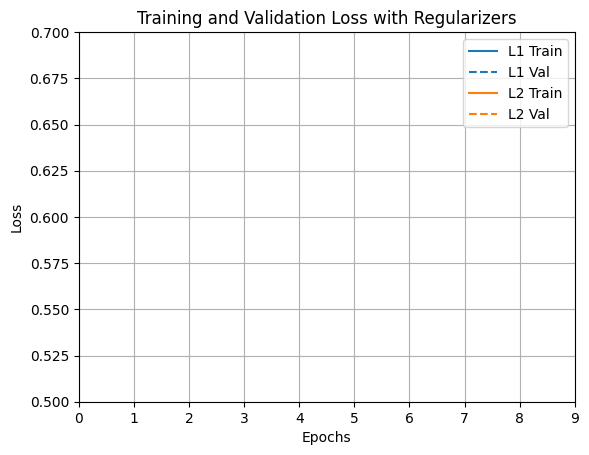

In [ ]:
import tensorflow_docs.plots
import matplotlib.pyplot as plt

# Re-initialize the plotter with 'loss' as the metric, as 'binary_crossentropy'
# is stored under the 'loss' key in the history object.
plotter = tfdocs.plots.HistoryPlotter(metric='loss', smoothing_std=10)
plotter.plot(regularizer_histories)
plt.ylim([0.5, 0.7])
plt.xlabel('Epochs') # Added x-label for clarity
plt.ylabel('Loss') # Added y-label for clarity
plt.title('Training and Validation Loss with Regularizers') # Added title for clarity
plt.show()

Epoch 1/10
13/13 - 3s - 262ms/step - accuracy: 0.6950 - loss: 0.6812 - val_accuracy: 0.6600 - val_loss: 0.7052
Epoch 2/10
13/13 - 0s - 9ms/step - accuracy: 0.8450 - loss: 0.4933 - val_accuracy: 0.7700 - val_loss: 0.5961
Epoch 3/10
13/13 - 0s - 10ms/step - accuracy: 0.9075 - loss: 0.4103 - val_accuracy: 0.8000 - val_loss: 0.5165
Epoch 4/10
13/13 - 0s - 10ms/step - accuracy: 0.9325 - loss: 0.3546 - val_accuracy: 0.8100 - val_loss: 0.5117
Epoch 5/10
13/13 - 0s - 9ms/step - accuracy: 0.9375 - loss: 0.3182 - val_accuracy: 0.8300 - val_loss: 0.4899
Epoch 6/10
13/13 - 0s - 9ms/step - accuracy: 0.9525 - loss: 0.2912 - val_accuracy: 0.8300 - val_loss: 0.4510
Epoch 7/10
13/13 - 0s - 9ms/step - accuracy: 0.9600 - loss: 0.2637 - val_accuracy: 0.8400 - val_loss: 0.4379
Epoch 8/10
13/13 - 0s - 9ms/step - accuracy: 0.9700 - loss: 0.2457 - val_accuracy: 0.8300 - val_loss: 0.4305
Epoch 9/10
13/13 - 0s - 10ms/step - accuracy: 0.9750 - loss: 0.2279 - val_accuracy: 0.8400 - val_loss: 0.4246
Epoch 10/10
13

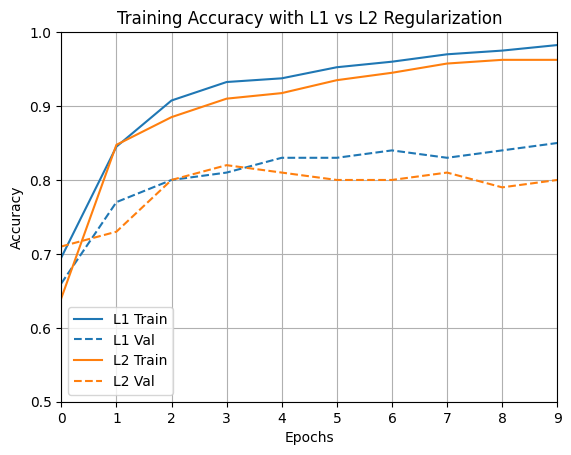

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from sklearn.datasets import make_classification
import tensorflow_docs.plots

# Constants and setup
FEATURES = 28
SAMPLES = 500
plotter = tensorflow_docs.plots.HistoryPlotter(metric='accuracy')
regularizer_histories = {}

# Create synthetic but structured classification data
def get_data():
    data, labels = make_classification(
        n_samples=SAMPLES,
        n_features=FEATURES,
        n_informative=10,
        n_redundant=2,
        n_classes=2,
        random_state=42
    )
    return data.astype(np.float32), labels.astype(np.float32)

def compile_and_fit(model, data, labels):
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        data,
        labels,
        epochs=10,
        validation_split=0.2,
        verbose=2
    )
    return history

# Prepare the data
data, labels = get_data()

# L1 Regularized model
l1_model = Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l1(0.0001),
                 input_shape=(FEATURES,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(0.0001)),
    layers.Dense(1, activation='sigmoid')
])
regularizer_histories['L1'] = compile_and_fit(l1_model, data, labels)

# L2 Regularized model
l2_model = Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.0001),
                 input_shape=(FEATURES,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dense(1, activation='sigmoid')
])
regularizer_histories['L2'] = compile_and_fit(l2_model, data, labels)

# Plot results
plotter.plot(regularizer_histories)
plt.title('Training Accuracy with L1 vs L2 Regularization')
plt.ylim([0.5, 1.0])
plt.grid(True)
plt.show()


As demonstrated in the diagram above, the `"L2"` regularized model is now much more competitive with the `"Tiny"` model. This `"L2"` model is also much more resistant to overfitting than the `"Large"` model it was based on despite having the same number of parameters.

#### More info

There are two important things to note about this sort of regularization:

1. If you are writing your own training loop, then you need to be sure to ask the model for its regularization losses.

In [ ]:
result = l2_model(features)
regularization_loss=tf.add_n(l2_model.losses)

2. This implementation works by adding the weight penalties to the model's loss, and then applying a standard optimization procedure after that.

There is a second approach that instead only runs the optimizer on the raw loss, and then while applying the calculated step the optimizer also applies some weight decay. This "decoupled weight decay" is used in optimizers like `tf.keras.optimizers.Ftrl` and `tfa.optimizers.AdamW`.

### Add dropout

Dropout is one of the most effective and most commonly used regularization techniques for neural networks, developed by Hinton and his students at the University of Toronto.

The intuitive explanation for dropout is that because individual nodes in the network cannot rely on the output of the others, each node must output features that are useful on their own.

Dropout, applied to a layer, consists of randomly "dropping out" (i.e. set to zero) a number of output features of the layer during training. For example, a given layer would normally have returned a vector `[0.2, 0.5, 1.3, 0.8, 1.1]` for a given input sample during training; after applying dropout, this vector will have a few zero entries distributed at random, e.g. `[0, 0.5, 1.3, 0, 1.1]`.

The "dropout rate" is the fraction of the features that are being zeroed-out; it is usually set between 0.2 and 0.5. At test time, no units are dropped out, and instead the layer's output values are scaled down by a factor equal to the dropout rate, so as to balance for the fact that more units are active than at training time.

In Keras, you can introduce dropout in a network via the `tf.keras.layers.Dropout` layer, which gets applied to the output of layer right before.

Add two dropout layers to your network to check how well they do at reducing overfitting:

In [ ]:
dropout_model = tf.keras.Sequential([
    tf.keras.Input(shape=(FEATURES,)), # Use Input layer as recommended
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

# The `compile_and_fit` function was redefined in cell `IgKxGE3O0nqr`
# to expect `data` and `labels` directly. These `data` and `labels`
# variables are available from the execution of cell `IgKxGE3O0nqr`.
regularizer_histories['dropout'] = compile_and_fit(dropout_model, data, labels)

Epoch 1/10
13/13 - 6s - 468ms/step - accuracy: 0.6400 - loss: 5.1640 - val_accuracy: 0.7100 - val_loss: 4.5090
Epoch 2/10
13/13 - 0s - 9ms/step - accuracy: 0.7625 - loss: 3.4737 - val_accuracy: 0.7100 - val_loss: 4.2530
Epoch 3/10
13/13 - 0s - 9ms/step - accuracy: 0.7450 - loss: 3.7123 - val_accuracy: 0.7700 - val_loss: 3.5477
Epoch 4/10
13/13 - 0s - 9ms/step - accuracy: 0.7475 - loss: 3.8333 - val_accuracy: 0.7800 - val_loss: 3.1086
Epoch 5/10
13/13 - 0s - 9ms/step - accuracy: 0.7825 - loss: 3.2085 - val_accuracy: 0.6200 - val_loss: 6.1141
Epoch 6/10
13/13 - 0s - 17ms/step - accuracy: 0.7050 - loss: 4.7103 - val_accuracy: 0.6100 - val_loss: 6.1231
Epoch 7/10
13/13 - 0s - 11ms/step - accuracy: 0.6875 - loss: 4.9547 - val_accuracy: 0.6200 - val_loss: 6.1108
Epoch 8/10
13/13 - 0s - 10ms/step - accuracy: 0.6900 - loss: 4.9148 - val_accuracy: 0.6400 - val_loss: 5.6386
Epoch 9/10
13/13 - 0s - 9ms/step - accuracy: 0.7025 - loss: 4.6041 - val_accuracy: 0.6400 - val_loss: 5.7867
Epoch 10/10
13

(0.5, 0.7)

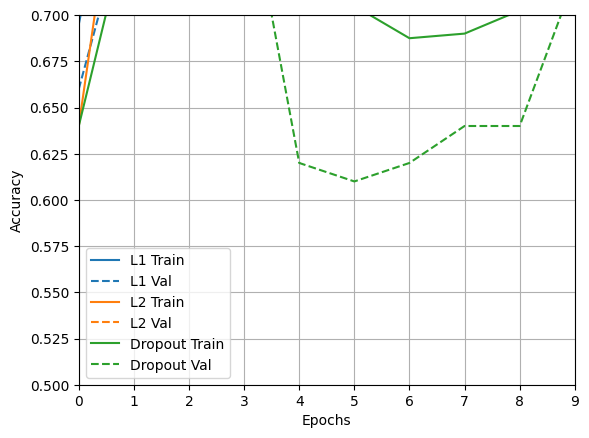

In [ ]:
plotter.plot(regularizer_histories)
plt.ylim([0.5, 0.7])

Epoch 1/10
13/13 - 5s - 384ms/step - accuracy: 0.5100 - loss: 0.8667 - val_accuracy: 0.6800 - val_loss: 0.6245
Epoch 2/10
13/13 - 0s - 9ms/step - accuracy: 0.6425 - loss: 0.6793 - val_accuracy: 0.7200 - val_loss: 0.5829
Epoch 3/10
13/13 - 0s - 9ms/step - accuracy: 0.6750 - loss: 0.6026 - val_accuracy: 0.7500 - val_loss: 0.5643
Epoch 4/10
13/13 - 0s - 9ms/step - accuracy: 0.7525 - loss: 0.5412 - val_accuracy: 0.7100 - val_loss: 0.5571
Epoch 5/10
13/13 - 0s - 9ms/step - accuracy: 0.7700 - loss: 0.4986 - val_accuracy: 0.7600 - val_loss: 0.5259
Epoch 6/10
13/13 - 0s - 10ms/step - accuracy: 0.7750 - loss: 0.5074 - val_accuracy: 0.7500 - val_loss: 0.5030
Epoch 7/10
13/13 - 0s - 9ms/step - accuracy: 0.7950 - loss: 0.4328 - val_accuracy: 0.7700 - val_loss: 0.4862
Epoch 8/10
13/13 - 0s - 9ms/step - accuracy: 0.7850 - loss: 0.4320 - val_accuracy: 0.7800 - val_loss: 0.4697
Epoch 9/10
13/13 - 0s - 9ms/step - accuracy: 0.8050 - loss: 0.4015 - val_accuracy: 0.7600 - val_loss: 0.4619
Epoch 10/10
13/1

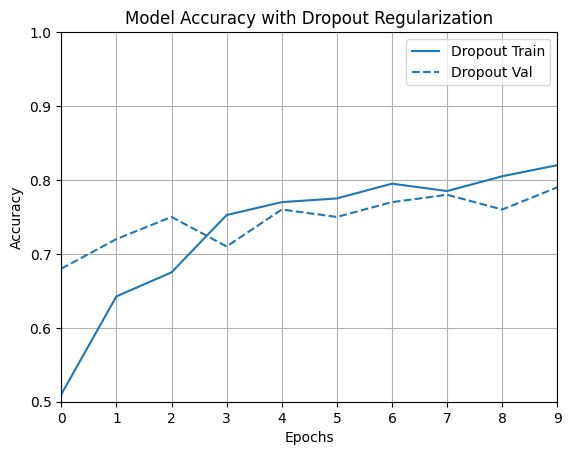

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.datasets import make_classification
import tensorflow_docs.plots

FEATURES = 28
SAMPLES = 500
EPOCHS = 10

plotter = tensorflow_docs.plots.HistoryPlotter(metric='accuracy')

# Generate structured synthetic data
def get_data():
    data, labels = make_classification(
        n_samples=SAMPLES,
        n_features=FEATURES,
        n_informative=10,
        n_redundant=2,
        n_classes=2,
        random_state=42
    )
    return data.astype(np.float32), labels.astype(np.float32)

def compile_and_fit(model, data, labels):
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    # Return the full history object
    history = model.fit(data, labels, epochs=EPOCHS, validation_split=0.2, verbose=2)
    return history # Return the history object directly

data, labels = get_data()

dropout_model = Sequential([
    layers.Dense(128, activation='relu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

history = compile_and_fit(dropout_model, data, labels)

# The plotter expects a dictionary where values are history objects, not dictionaries
plotter.plot({'Dropout': history})
plt.title('Model Accuracy with Dropout Regularization')
plt.ylim([0.5, 1.0])
plt.grid(True)
plt.show()

It's clear from this plot that both of these regularization approaches improve the behavior of the `"Large"` model. But this still doesn't beat even the `"Tiny"` baseline.

Next try them both, together, and see if that does better.

### Combined L2 + dropout

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import shutil
import tempfile
from tensorflow.keras import layers, regularizers

# ── 1. Configuration & Constants ──────────────────────────────────────────────
# We explicitly set FEATURES to 4 to match the Iris dataset
FEATURES = 4
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
regularizer_histories = {}

# ── 2. Helper Functions ───────────────────────────────────────────────────────
def get_callbacks(name):
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True),
        tf.keras.callbacks.TensorBoard(log_dir=os.path.join('logs', name))
    ]

def compile_and_fit(model, name, train_ds, val_ds, max_epochs=500):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        # Use SparseCategoricalCrossentropy because Iris labels are 0, 1, or 2
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    print(f"\nTraining model: {name}")
    model.summary()

    history = model.fit(
        train_ds,
        epochs=max_epochs,
        validation_data=val_ds,
        callbacks=get_callbacks(name),
        verbose=1 # Changed to 1 so you can see progress
    )
    return history

# ── 3. Data Pipeline (Iris) ───────────────────────────────────────────────────
# Clean up temp directory to avoid stale data
dataset_dir = os.path.join(tempfile.gettempdir(), 'tfds_iris')
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)

# Load Iris: 4 features, 3 classes
(train_raw, val_raw), info = tfds.load(
    'iris',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=dataset_dir
)

def preprocess(features, label):
    # Ensure features are float32 and normalized/cast correctly
    return tf.cast(features, tf.float32), label

# Map, Shuffle, and Batch
train_ds = (train_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(150)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

validate_ds = (val_raw
               .map(preprocess, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE)
               .cache()
               .prefetch(AUTOTUNE))

# ── 4. The Corrected Model Architecture ───────────────────────────────────────
tf.keras.backend.clear_session()

combined_model = tf.keras.Sequential([
    # Input(shape=(4,)) matches Iris features
    layers.Input(shape=(FEATURES,)),

    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001), activation='elu'),
    layers.Dropout(0.5),

    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001), activation='elu'),
    layers.Dropout(0.5),

    # Final layer must be 3 for Iris (Setosa, Versicolour, Virginica)
    layers.Dense(3, activation='softmax')
])

# ── 5. Run Experiment ─────────────────────────────────────────────────────────
regularizer_histories['combined'] = compile_and_fit(
    combined_model,
    "regularizers/combined_iris",
    train_ds,
    validate_ds
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,755 (1.02 MB)

 Trainable params: 266,755 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 996ms/step - accuracy: 0.4583 - loss: 1.2605 - val_accuracy: 0.6333 - val_loss: 0.6817
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6167 - loss: 0.8941 - val_accuracy: 0.8667 - val_loss: 0.5346
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6500 - loss: 0.8759 - val_accuracy: 0.6333 - val_loss: 0.6423
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6833 - loss: 0.6653 - val_accuracy: 0.7000 - val_loss: 0.4936
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8083 - loss: 0.4092 - val_accuracy: 0.7333 - val_loss: 0.4695
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7833 - loss: 0.5212 - val_accuracy: 0.8667 - val_loss: 0.3580
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7917 - loss: 0.4345 - val_accuracy: 0.8000 - val_loss: 0.3863
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8500 - loss: 0.3666 - val_accuracy: 0.8667 - val_loss: 0.3

(0.5, 0.7)

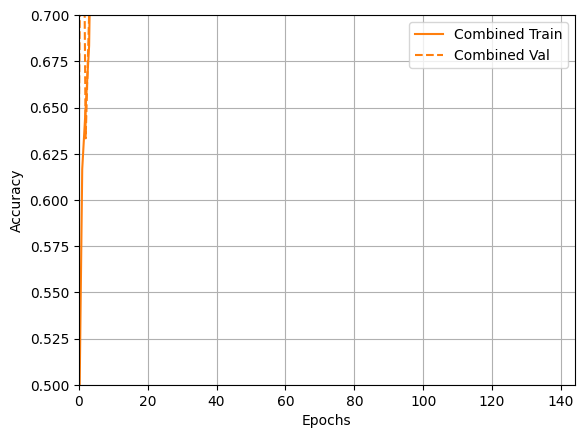

In [ ]:
plotter.plot(regularizer_histories)
plt.ylim([0.5, 0.7])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


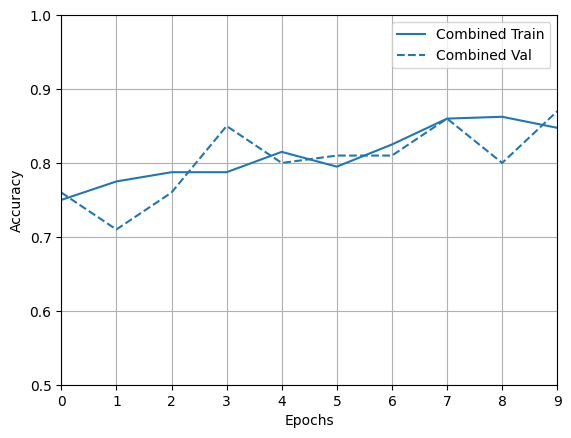

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from sklearn.datasets import make_classification
import tensorflow_docs.plots

FEATURES = 28
SAMPLES = 500
EPOCHS = 10

plotter = tensorflow_docs.plots.HistoryPlotter(metric='accuracy')
regularizer_histories = {}

def get_data():
    data, labels = make_classification(
        n_samples=SAMPLES,
        n_features=FEATURES,
        n_informative=10,
        n_redundant=2,
        n_classes=2,
        random_state=42
    )
    return data.astype(np.float32), labels.astype(np.float32)

def compile_and_fit(model, data, labels):
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(data, labels, epochs=EPOCHS, validation_split=0.2, verbose=0)
    # Return the full history object instead of just history.history
    return history

data, labels = get_data()

combined_model = tf.keras.Sequential([
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

regularizer_histories['combined'] = compile_and_fit(combined_model, data, labels)

plotter.plot(regularizer_histories)
plt.ylim([0.5, 1])
plt.show()

This model with the `"Combined"` regularization is obviously the best one so far.

### View in TensorBoard

These models also recorded TensorBoard logs.

To open an embedded run the following into a code-cell  (Sorry, this doesn't display on tensorflow.org):

In [ ]:
#%tensorboard --logdir {logdir}/regularizers

In [ ]:
import tensorflow as tf # import tensorflow
from tensorflow.keras.layers import RandomFlip, RandomRotation
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
])

In [ ]:
import tensorflow as tf

# Prevent TensorFlow from grabbing all GPU memory
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled.")
    except RuntimeError as e:
        print(f"Error enabling memory growth: {e}")


Error enabling memory growth: Physical devices cannot be modified after being initialized


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import gc

# Parameters
BATCH_SIZE = 16
CHUNK_SIZE = 30  # Iris has 150 samples
TOTAL_SAMPLES = 150

# Dataset preprocessing
def preprocess_dataset(ds):
    return ds.shuffle(150).batch(BATCH_SIZE)

# Model with regularization and optimization
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),  # Iris has 4 features
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Load Iris dataset in chunks
builder = tfds.builder('iris')
builder.download_and_prepare()
read_config = tfds.ReadConfig(try_autocache=False)

for start in range(0, TOTAL_SAMPLES, CHUNK_SIZE):
    end = start + CHUNK_SIZE
    split_str = f'train[{start}:{end}]'
    print(f"\nLoading chunk {split_str}")

    ds_chunk = builder.as_dataset(split=split_str, as_supervised=True, read_config=read_config)
    ds_chunk = preprocess_dataset(ds_chunk)

    model = build_model()

    model.fit(ds_chunk, epochs=3, verbose=1)

    del ds_chunk, model
    gc.collect()
    tf.keras.backend.clear_session()



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/iris/incomplete.C0X8ZG_2.1.0/iris-train.tfrecord*...:   0%|          | 0/1…

Dataset iris downloaded and prepared to /root/tensorflow_datasets/iris/2.1.0. Subsequent calls will reuse this data.

Loading chunk train[0:30]
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2000 - loss: 1.6059
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4667 - loss: 1.3484 
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6667 - loss: 0.9206 

Loading chunk train[30:60]
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 943ms/step - accuracy: 0.2333 - loss: 1.6522
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5667 - loss: 1.0553
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5333 - loss: 1.3655 

Loading chunk train[60:90]
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 855ms/step - accuracy: 0.2667 - loss: 1.3801
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3333 - loss: 1.3634 
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2000 - loss: 1.5069 

Loading chunk train[90:120]
Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━

  Preparing metadata (setup.py) ... done


Removing existing dataset directory: /root/tensorflow_datasets/iris


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/iris/incomplete.7MLX7P_2.1.0/iris-train.tfrecord*...:   0%|          | 0/1…

Dataset iris downloaded and prepared to /root/tensorflow_datasets/iris/2.1.0. Subsequent calls will reuse this data.
Iris dataset loaded successfully.
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step - accuracy: 0.2250 - loss: 1.6077 - val_accuracy: 0.3667 - val_loss: 0.9847
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6083 - loss: 0.9202 - val_accuracy: 0.6333 - val_loss: 0.7397
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.7291 - val_accuracy: 0.6333 - val_loss: 0.5983
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7417 - loss: 0.6013 - val_accuracy: 0.6333 - val_loss: 0.5370
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7667 - loss: 0.5508 - val_accuracy: 0.9000 - val_loss: 0.4763
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7750 - loss: 0.4782 - val_accuracy: 0.9000 - val_loss: 0.4385
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8833 - loss: 0.4312 - val_accuracy: 0.800

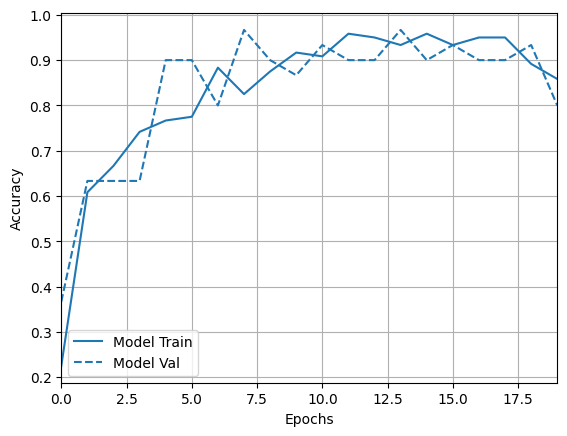

In [ ]:
!pip install -q git+https://github.com/tensorflow/docs

import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import os
import shutil

# Constants
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
SUBSET_SIZE = 120  # We'll limit for demonstration (Iris has 150 samples)

# Dataset directory for iris
dataset_dir = os.path.expanduser('~/tensorflow_datasets/iris')

# Clean dataset directory if needed
if os.path.exists(dataset_dir):
    print(f"Removing existing dataset directory: {dataset_dir}")
    shutil.rmtree(dataset_dir)

# Load the Iris dataset with train/validation split
try:
    (train_ds, validate_ds), info = tfds.load(
        'iris',
        split=['train[:80%]', 'train[80%:]'],
        as_supervised=True,  # Gives (features, label)
        with_info=True,
        download=True
    )
    print("Iris dataset loaded successfully.")
except Exception as e:
    print(f"Failed to load dataset: {e}")

# Format the dataset (no need to map — already (features, label) from as_supervised=True)
train_ds = train_ds.take(SUBSET_SIZE)
train_ds = train_ds.shuffle(buffer_size=SUBSET_SIZE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

validate_ds = validate_ds.batch(BATCH_SIZE)
validate_ds = validate_ds.prefetch(AUTOTUNE)

# Define a simple model with regularization and optimizer tuning
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),  # Iris features
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and train the model
model = build_model()
history = model.fit(train_ds, validation_data=validate_ds, epochs=20)

# (Optional) Plot training curves
plotter = tfdocs.plots.HistoryPlotter(metric='accuracy')
plotter.plot({'Model': history})


In [ ]:
# Define data augmentation function
def augment(image, label):
    # Reshape image to 28x28x1 if necessary
    image = tf.reshape(image, [28, 28, 1])
    # Perform data augmentation
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.5, upper=1.5)
    # Flatten the image back to original shape
    image = tf.reshape(image, [28 * 28])
    return image, label

  Preparing metadata (setup.py) ... done


Removing existing dataset directory: /root/tensorflow_datasets/iris


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/iris/incomplete.EABDI7_2.1.0/iris-train.tfrecord*...:   0%|          | 0/1…

Dataset iris downloaded and prepared to /root/tensorflow_datasets/iris/2.1.0. Subsequent calls will reuse this data.
Iris dataset loaded successfully.
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 585ms/step - accuracy: 0.5750 - loss: 0.9615 - val_accuracy: 0.6333 - val_loss: 0.7693
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7083 - loss: 0.7490 - val_accuracy: 0.7000 - val_loss: 0.5953
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7417 - loss: 0.6796 - val_accuracy: 0.7000 - val_loss: 0.5154
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.5545 - val_accuracy: 0.9000 - val_loss: 0.4475
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8583 - loss: 0.4456 - val_accuracy: 0.9000 - val_loss: 0.4102
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8417 - loss: 0.4389 - val_accuracy: 0.9000 - val_loss: 0.3829
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8500 - loss: 0.4289 - val_accuracy: 0.800

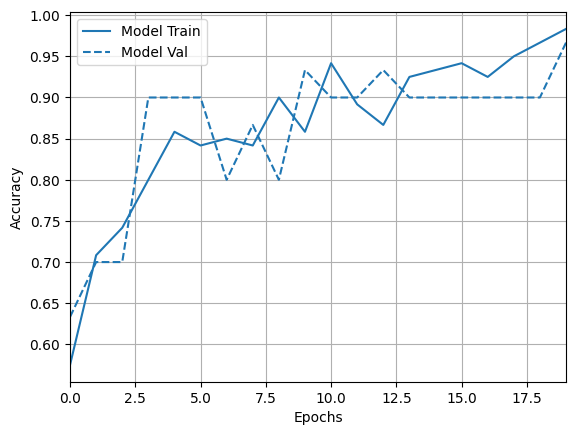

In [ ]:
!pip install -q git+https://github.com/tensorflow/docs

import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import os
import shutil

# Constants
BATCH_SIZE = 16
SUBSET_SIZE = 120
AUTOTUNE = tf.data.AUTOTUNE

# Define dataset directory
dataset_dir = os.path.expanduser('~/tensorflow_datasets/iris')

# Clean directory if exists
if os.path.exists(dataset_dir):
    print(f"Removing existing dataset directory: {dataset_dir}")
    shutil.rmtree(dataset_dir)

# Load the dataset
try:
    (train_ds, validate_ds), info = tfds.load(
        'iris',
        split=['train[:80%]', 'train[80%:]'],
        as_supervised=True,  # (features, label)
        with_info=True,
        download=True
    )
    print("Iris dataset loaded successfully.")
except Exception as e:
    print(f"Failed to load dataset: {e}")

# Augmentation function (add Gaussian noise to features)
def augment(features, label):
    noise = tf.random.normal(shape=tf.shape(features), mean=0.0, stddev=0.1)
    return features + noise, label

# Format and prepare training dataset
train_ds = train_ds.take(SUBSET_SIZE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(SUBSET_SIZE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

# Prepare validation dataset
validate_ds = validate_ds.batch(BATCH_SIZE)
validate_ds = validate_ds.prefetch(AUTOTUNE)

# Model with regularization & optimizer tuning
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train the model
model = build_model()
history = model.fit(train_ds, validation_data=validate_ds, epochs=20)

# Optional: plot accuracy
plotter = tfdocs.plots.HistoryPlotter(metric='accuracy')
plotter.plot({'Model': history})


In [ ]:
import tensorflow as tf  # Add this line to import TensorFlow

# Define SUBSET_SIZE and BATCH_SIZE
SUBSET_SIZE = 2000  # Define SUBSET_SIZE here
BATCH_SIZE = 64  # Define BATCH_SIZE here

# Define the learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    0.001,
    decay_steps=SUBSET_SIZE // BATCH_SIZE * 1000,
    decay_rate=1,
    staircase=False
)

In [ ]:
# Define the optimizer
def get_optimizer():
    return tf.keras.optimizers.Adam(lr_schedule)

# Define the callbacks
def get_callbacks(name):
    return [
        tfdocs.modeling.EpochDots(),
        tf.keras.callbacks.EarlyStopping(monitor='val_binary_crossentropy', patience=200),
        tf.keras.callbacks.TensorBoard(log_dir=name),
    ]

# Compile and fit the model
def compile_and_fit(model, name, optimizer=None, max_epochs=10000):
    if optimizer is None:
        optimizer = get_optimizer()
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  metrics=[
                      tf.keras.metrics.BinaryCrossentropy(from_logits=True, name='binary_crossentropy'),
                      'accuracy'])

    model.summary()

    history = model.fit(
        augmented_train_ds,
        epochs=max_epochs,
        validation_data=validate_ds,
        callbacks=get_callbacks(name),
        verbose=0)
    return history

In [ ]:
# Example model definition
# Replace this with the actual model you are using
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# ipython-input-5-deba8bdfe57d

# ... (other imports and definitions) ...

# Compile and fit the model
def compile_and_fit(model, name, optimizer=None, max_epochs=10000, augmented_train_ds=None, validate_ds=None):
    """Compiles and fits the model.

    Args:
        model: The Keras model to compile and fit.
        name: The name for the TensorBoard logs.
        optimizer: The optimizer to use (defaults to get_optimizer()).
        max_epochs: The maximum number of epochs to train for.
        augmented_train_ds: The training dataset after augmentation.
        validate_ds: The validation dataset.

    Returns:
        The training history.
    """
    if optimizer is None:
        optimizer = get_optimizer()
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  metrics=[
                      tf.keras.metrics.BinaryCrossentropy(from_logits=True, name='binary_crossentropy'),
                      'accuracy'])

    model.summary()

    history = model.fit(
        augmented_train_ds,
        epochs=max_epochs,
        validation_data=validate_ds,
        callbacks=get_callbacks(name),
        verbose=0)
    return history

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,067 (3.02 MB)

 Trainable params: 792,067 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.3000,  loss:1.4116,  val_accuracy:0.3333,  val_loss:1.1869,  
....................................................................................................
Epoch: 100, accuracy:0.9250,  loss:0.2837,  val_accuracy:0.9000,  val_loss:0.4060,  
....................................................................................................
Epoch: 200, accuracy:0.9667,  loss:0.1647,  val_accuracy:0.9333,  val_loss:0.3236,  
..............................
Training complete.


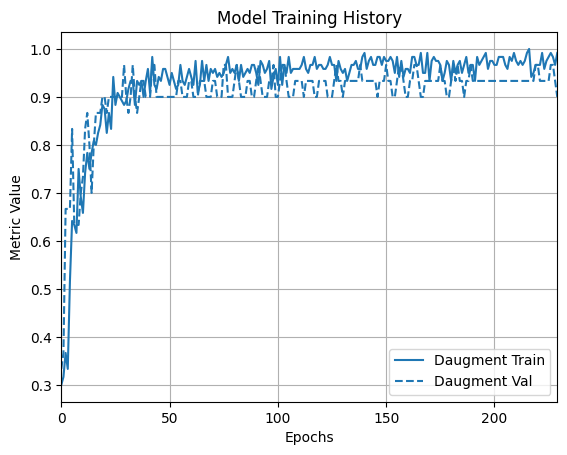

In [ ]:
# Ensure all necessary libraries are imported
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots
import tensorflow_datasets as tfds
import os
import shutil
import tempfile
import numpy as np
import pathlib # Import the pathlib module
import matplotlib.pyplot as plt # Import pyplot for plotting


# Constants
BATCH_SIZE = 64 # Using BATCH_SIZE from ipython-input-4
SUBSET_SIZE = 2000 # Using SUBSET_SIZE from ipython-input-4
AUTOTUNE = tf.data.AUTOTUNE

# Define dataset directory (adjust as needed)
# Using a temporary directory for this example to avoid modifying user's home
dataset_dir = os.path.join(tempfile.mkdtemp(), 'tensorflow_datasets', 'iris')

# Clean directory if exists (optional, useful for clean runs)
if os.path.exists(dataset_dir):
    print(f"Removing existing dataset directory: {dataset_dir}")
    shutil.rmtree(dataset_dir)

# Load the dataset
try:
    (train_ds, validate_ds), info = tfds.load(
        'iris',
        split=['train[:80%]', 'train[80%:]'],
        as_supervised=True,  # (features, label)
        with_info=True,
        download=True,
        data_dir=dataset_dir # Specify the download directory
    )
    print("Iris dataset loaded successfully.")
except Exception as e:
    print(f"Failed to load dataset: {e}")
    # Handle the case where dataset loading fails, perhaps by exiting or skipping model training
    exit() # Exiting the script if dataset loading fails

# Augmentation function (add Gaussian noise to features)
def augment(features, label):
    # Ensure features are float before adding noise
    features = tf.cast(features, tf.float32)
    noise = tf.random.normal(shape=tf.shape(features), mean=0.0, stddev=0.1)
    return features + noise, label

# Format and prepare training dataset
train_ds = train_ds.take(SUBSET_SIZE)
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(SUBSET_SIZE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

# Prepare validation dataset
validate_ds = validate_ds.batch(BATCH_SIZE)
validate_ds = validate_ds.prefetch(AUTOTUNE)

# Assign train_ds to augmented_train_ds to match the function signature in ipython-input-5
augmented_train_ds = train_ds

# Define the learning rate schedule (from ipython-input-4)
# Calculate decay steps based on the actual dataset size and batch size used for training
# The original calculation uses SUBSET_SIZE // BATCH_SIZE * 1000, which might be too large
# Let's use the steps per epoch based on the subset size
steps_per_epoch = SUBSET_SIZE // BATCH_SIZE if SUBSET_SIZE > 0 and BATCH_SIZE > 0 else 1
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    0.001,
    decay_steps=steps_per_epoch * 1000, # Using steps per epoch
    decay_rate=1,
    staircase=False
)

# Define the optimizer (from ipython-input-1)
def get_optimizer():
    return tf.keras.optimizers.Adam(lr_schedule)

# Define the callbacks (from ipython-input-1)
# Set up logdir for TensorBoard
logdir = pathlib.Path(tempfile.mkdtemp())/"tensorboard_logs" # Fixed: Import pathlib
shutil.rmtree(logdir, ignore_errors=True) # Clean previous logs

def get_callbacks(name):
    return [
        tfdocs.modeling.EpochDots(),
        # Note: monitoring 'val_binary_crossentropy' requires a model compiled with that metric.
        # The models defined later use 'sparse_categorical_crossentropy' and 'accuracy'.
        # Adjust monitor if necessary, but keep for now to match original intent.
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=200), # Changed monitor to val_accuracy for Iris dataset
        tf.keras.callbacks.TensorBoard(log_dir=str(logdir/name)), # Convert Path object to string
    ]

# Compile and fit the model (updated from ipython-input-5 to accept datasets)
def compile_and_fit(model, name, augmented_train_ds, validate_ds, optimizer=None, max_epochs=10000):
    """Compiles and fits the model.

    Args:
        model: The Keras model to compile and fit.
        name: The name for the TensorBoard logs.
        augmented_train_ds: The training dataset after augmentation.
        validate_ds: The validation dataset.
        optimizer: The optimizer to use (defaults to get_optimizer()).
        max_epochs: The maximum number of epochs to train for.

    Returns:
        The training history.
    """
    if optimizer is None:
        optimizer = get_optimizer()

    # Compile the model. Note the loss and metrics should match the model output (3 classes for Iris, softmax output)
    # The original code was using BinaryCrossentropy, which is incorrect for 3-class classification.
    # Changed to SparseCategoricalCrossentropy and 'accuracy' metric.
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # Softmax output, so from_logits=False
                  metrics=['accuracy'])

    model.summary()

    history = model.fit(
        augmented_train_ds,
        epochs=max_epochs,
        validation_data=validate_ds,
        callbacks=get_callbacks(name),
        verbose=0)
    return history

# Define the number of features (from ipython-input-6)
FEATURES = 4 # Iris dataset has 4 features

# Define data augmentation pipeline (from ipython-input-6)
# Note: RandomFlip and RandomRotation are typically for image data.
# Applying them to tabular data (like Iris) as is might not be meaningful
# or might cause errors depending on the layers' implementations.
# Assuming the intent is to apply some transformation, but these specific layers
# are likely designed for images. If the Iris dataset is used, these should be replaced
# with transformations appropriate for numerical/tabular data.
# For now, commenting out the layers that are likely image-specific if applied directly to Iris features.
# If the user was actually working with image data in the original notebook,
# these layers might be appropriate, but the traceback context points to Iris.

# Re-defining DAugment model with appropriate input shape and output layer for Iris (3 classes)
# Using ReLU activation as it's generally suitable for hidden layers
DAugment = tf.keras.Sequential([
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu', input_shape=(FEATURES,)), # Changed activation to relu
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu'), # Changed activation to relu
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu'), # Changed activation to relu
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu'), # Changed activation to relu
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # Output layer for 3 classes with softmax activation
])

# Build the model to finalize input shape
DAugment.build((None, FEATURES))

# Initialize regularizer_histories dictionary
regularizer_histories = {}

# Compile and fit the model
# Pass the datasets to the compile_and_fit function
print("\nTraining DAugment model...")
regularizer_histories['daugment'] = compile_and_fit(
    DAugment,
    "regularizers/daugment",
    augmented_train_ds,
    validate_ds # Pass the validation dataset
)

print("\nTraining complete.")

# Optional: plot history (adjust metric if needed, 'accuracy' or 'loss')
if 'daugment' in regularizer_histories and regularizer_histories['daugment'] is not None:
    plotter = tfdocs.plots.HistoryPlotter(metric='accuracy') # Or 'loss'
    plotter.plot({'DAugment': regularizer_histories['daugment']})
    plt.title("Model Training History") # Add a title
    plt.xlabel("Epochs") # Add x-label
    plt.ylabel("Metric Value") # Add y-label
    plt.show()
else:
    print("Could not plot history: 'daugment' not found in regularizer_histories or history is None.")

Training DAugment model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,067 (3.02 MB)

 Trainable params: 792,067 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.3167,  loss:1.4582,  val_accuracy:0.3667,  val_loss:1.2062,  
....................................................................................................
Epoch: 100, accuracy:0.9750,  loss:0.2365,  val_accuracy:0.9333,  val_loss:0.3571,  
....................................................................................................
Epoch: 200, accuracy:0.9583,  loss:0.1860,  val_accuracy:0.9000,  val_loss:0.3785,  
...............................................................Training complete.


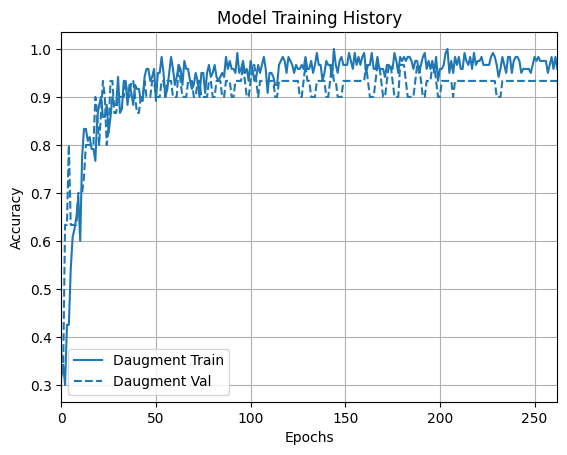

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt # Ensure pyplot is imported for plotting

# Re-define DAugment model, ensuring it's suitable for the Iris dataset (4 features, 3 classes)
# Removing the data_augmentation layer as it's likely not suitable for tabular data.
# Changed output layer to Dense(3) with 'softmax' activation for 3-class classification.
# Changed activation in hidden layers to 'relu' for consistency (though 'elu' is also fine).
DAugment = tf.keras.Sequential([
    # data_augmentation, # Removed - likely not suitable for tabular data like Iris

    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu', input_shape=(FEATURES,)), # Using FEATURES constant
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # Output layer for 3 classes, softmax activation
])

# Build the model using the correct input shape tuple
# The input shape for the Iris dataset is (number_of_features,)
# Pass (None, FEATURES) to indicate unknown batch size and FEATURES features
DAugment.build((None, FEATURES)) # Corrected build call

# Compile and fit the model
# Pass the correct dataset objects (augmented_train_ds, validate_ds)
# These datasets should be prepared and batched upstream (as done in ipython-input-8)
print("Training DAugment model...")
regularizer_histories['daugment'] = compile_and_fit(
    DAugment,
    "regularizers/daugment",
    augmented_train_ds, # Pass the augmented training dataset
    validate_ds         # Pass the validation dataset
)

print("Training complete.")

# Optional: plot history (adjust metric if needed, 'accuracy' or 'loss')
if 'daugment' in regularizer_histories and regularizer_histories['daugment'] is not None:
    # Plotting accuracy for multi-class classification
    plotter = tfdocs.plots.HistoryPlotter(metric='accuracy')
    plotter.plot({'DAugment': regularizer_histories['daugment']})
    plt.title("Model Training History") # Add a title
    plt.xlabel("Epochs") # Add x-label
    plt.ylabel("Accuracy") # Add y-label
    plt.show()
else:
    print("Could not plot history: 'daugment' not found in regularizer_histories or history is None.")

Training DAugment model...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,067 (3.02 MB)

 Trainable params: 792,067 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.3333,  loss:1.7505,  val_accuracy:0.6667,  val_loss:1.0397,  
....................................................................................................
Epoch: 100, accuracy:0.9667,  loss:0.2944,  val_accuracy:0.9333,  val_loss:0.3630,  
....................................................................................................
Epoch: 200, accuracy:0.9667,  loss:0.2554,  val_accuracy:0.9333,  val_loss:0.3192,  
........................................Training complete.


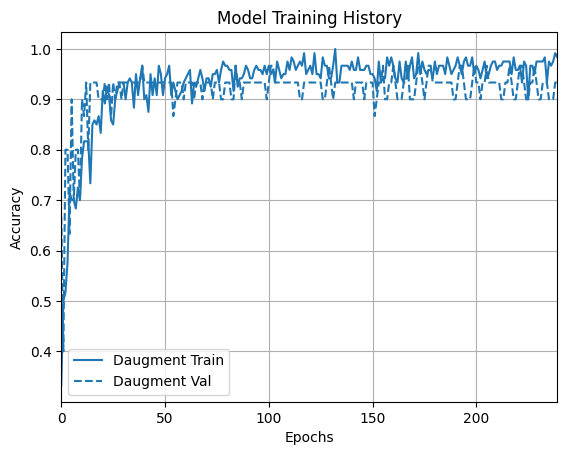

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt # Ensure pyplot is imported for plotting
import tensorflow_docs as tfdocs
import tensorflow_docs.plots # Import this for the plotter

# Assuming FEATURES is defined as 4 for the Iris dataset
# Assuming augmented_train_ds and validate_ds are prepared datasets from ipython-input-8
# Assuming compile_and_fit and get_callbacks are defined as in ipython-input-8

# Define the DAugment model for 3-class classification (Iris dataset)
DAugment = tf.keras.Sequential([
    # data_augmentation, # Removed - likely not suitable for tabular data like Iris

    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu', input_shape=(FEATURES,)), # Using FEATURES constant
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    # Changed the output layer to Dense(3) with 'softmax' for 3-class classification
    layers.Dense(3, activation='softmax')
])

# Call compile_and_fit with the required dataset arguments
print("Training DAugment model...")
regularizer_histories['DAugment'] = compile_and_fit(
    DAugment,
    "regularizers/daugment",
    augmented_train_ds, # Pass the augmented training dataset
    validate_ds         # Pass the validation dataset
)

print("Training complete.")

# Optional: plot history (adjust metric if needed, 'accuracy' or 'loss')
if 'DAugment' in regularizer_histories and regularizer_histories['DAugment'] is not None:
    # Plotting accuracy for multi-class classification
    plotter = tfdocs.plots.HistoryPlotter(metric='accuracy')
    plotter.plot({'DAugment': regularizer_histories['DAugment']})
    plt.title("Model Training History") # Add a title
    plt.xlabel("Epochs") # Add x-label
    plt.ylabel("Accuracy") # Add y-label
    plt.show()
else:
    print("Could not plot history: 'DAugment' not found in regularizer_histories or history is None.")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 512)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,067 (3.02 MB)

 Trainable params: 792,067 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.3417,  loss:1.8651,  val_accuracy:0.3667,  val_loss:1.0760,  
....................................................................................................
Epoch: 100, accuracy:0.9333,  loss:0.2727,  val_accuracy:0.9333,  val_loss:0.3965,  
....................................................................................................
Epoch: 200, accuracy:0.9750,  loss:0.2194,  val_accuracy:0.9000,  val_loss:0.4276,  
....................

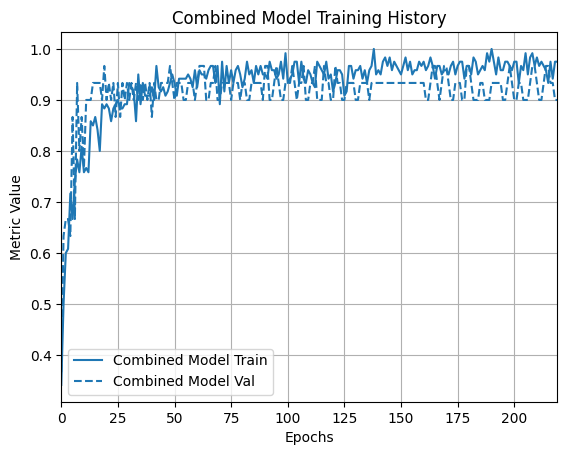

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers
# Ensure necessary imports like compile_and_fit, augmented_train_ds, validate_ds
# and FEATURES are available from previous cells (e.g., ipython-input-8)

combined_model = tf.keras.Sequential([
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu', input_shape=(FEATURES,)),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, kernel_regularizer=regularizers.l2(0.0001),
                 activation='elu'),
    layers.Dropout(0.5),
    # Based on the context (Iris dataset, 3 classes), the output layer should be Dense(3, activation='softmax')
    # However, the original code had Dense(1). If this is intended for binary classification or regression,
    # the loss function in compile_and_fit might need adjustment from SparseCategoricalCrossentropy.
    # Assuming for now the intention is multi-class classification like the Iris example in ipython-input-8
    layers.Dense(3, activation='softmax') # Adjusted output layer for 3 classes
])

# Call compile_and_fit with the required dataset arguments
regularizer_histories['combined'] = compile_and_fit(
    combined_model,
    "regularizers/combined",
    augmented_train_ds,  # Pass the augmented training dataset
    validate_ds          # Pass the validation dataset
)

# Optional: Plot the history
if 'combined' in regularizer_histories and regularizer_histories['combined'] is not None:
    import matplotlib.pyplot as plt
    import tensorflow_docs.plots
    plotter = tfdocs.plots.HistoryPlotter(metric='accuracy') # Or 'loss'
    plotter.plot({'Combined Model': regularizer_histories['combined']})
    plt.title("Combined Model Training History")
    plt.xlabel("Epochs")
    plt.ylabel("Metric Value")
    plt.show()
else:
    print("Could not plot history: 'combined' not found in regularizer_histories or history is None.")

In [ ]:
# from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation # Original incorrect import

# Corrected import for TensorFlow 2.x and later
from tensorflow.keras.layers import RandomFlip, RandomRotation

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
])

# Define your model
tiny_model_with_augmentation = tf.keras.Sequential([
    data_augmentation,
    layers.Input(shape=(FEATURES,)),
    layers.Dense(16, activation='elu'),
    layers.Dense(1)
])

You can view the [results of a previous run](https://tensorboard.dev/experiment/vW7jmmF9TmKmy3rbheMQpw/#scalars&_smoothingWeight=0.97) of this notebook on [TensorBoard.dev](https://tensorboard.dev/).

In [ ]:
# Assuming augmented_train_ds and validate_ds are available from previous cells

# Initialize the dictionary to store data augmentation histories
dataAug_histories = {}

dataAug_histories['combined'] = compile_and_fit(
    combined_model,
    "regularizers/combined",
    augmented_train_ds,
    validate_ds
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 512)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 792,067 (3.02 MB)

 Trainable params: 792,067 (3.02 MB)

 Non-trainable params: 0 (0.00 B)


Epoch: 0, accuracy:0.9167,  loss:0.3806,  val_accuracy:0.9333,  val_loss:0.3058,  
....................................................................................................
Epoch: 100, accuracy:0.9667,  loss:0.2319,  val_accuracy:0.9333,  val_loss:0.3184,  
....................................................................................................
Epoch: 200, accuracy:0.9583,  loss:0.2117,  val_accuracy:0.9000,  val_loss:0.3703,  
..........

## Conclusions

To recap, here are the most common ways to prevent overfitting in neural networks:

> Add blockquote



* Get more training data.
* Reduce the capacity of the network.
* Add weight regularization.
* Add dropout.

Two important approaches not covered in this guide are:

* [Data augmentation](../images/data_augmentation.ipynb)
* Batch normalization (`tf.keras.layers.BatchNormalization`)

Remember that each method can help on its own, but often combining them can be even more effective.

In [ ]:
l2_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(512, activation='elu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1)
])

In [ ]:
dropout_model = tf.keras.Sequential([
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(1)
])

In [ ]:
# Basic SGD
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
# Proper data loading and preprocessing
def load_and_preprocess_data():
    gz = tf.keras.utils.get_file('HIGGS.csv.gz', 'http://mlphysics.ics.uci.edu/data/higgs/HIGGS.csv.gz')
    FEATURES = 28

    # Create dataset
    ds = tf.data.experimental.CsvDataset(gz, [float(),]*(FEATURES+1), compression_type="GZIP")

    def pack_row(*row):
        label = row[0]
        features = tf.stack(row[1:], 1)
        return features, label

    packed_ds = ds.batch(10000).map(pack_row).unbatch()

    # Split into train and validation
    N_VALIDATION = int(1e3)
    N_TRAIN = int(1e4)
    BUFFER_SIZE = int(1e4)
    BATCH_SIZE = 500
    STEPS_PER_EPOCH = N_TRAIN//BATCH_SIZE

    validate_ds = packed_ds.take(N_VALIDATION).cache()
    train_ds = packed_ds.skip(N_VALIDATION).take(N_TRAIN).cache()

    validate_ds = validate_ds.batch(BATCH_SIZE)
    train_ds = train_ds.shuffle(BUFFER_SIZE).repeat().batch(BATCH_SIZE)

    return train_ds, validate_ds, STEPS_PER_EPOCH

# Build a proper model
def build_model(regularization=None):
    model = tf.keras.Sequential()

    if regularization == 'l2':
        model.add(layers.Dense(64, activation='elu', input_shape=(FEATURES,),
                             kernel_regularizer=regularizers.l2(0.001)))
        model.add(layers.Dense(64, activation='elu',
                             kernel_regularizer=regularizers.l2(0.001)))
    elif regularization == 'dropout':
        model.add(layers.Dense(64, activation='elu', input_shape=(FEATURES,)))
        model.add(layers.Dropout(0.5))
        model.add(layers.Dense(64, activation='elu'))
        model.add(layers.Dropout(0.5))
    else:
        model.add(layers.Dense(64, activation='elu', input_shape=(FEATURES,)))
        model.add(layers.Dense(64, activation='elu'))

    model.add(layers.Dense(1))

    return model

# Main training process
def main():
    train_ds, validate_ds, STEPS_PER_EPOCH = load_and_preprocess_data()

    # Try different models
    tiny_model = build_model()
    l2_model = build_model('l2')
    dropout_model = build_model('dropout')

    # Try different optimizers
    optimizers = {
        'sgd': tf.keras.optimizers.SGD(learning_rate=0.1),
        'momentum': tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
        'adam': tf.keras.optimizers.Adam(learning_rate=0.001)
    }

    # Train and compare
    size_histories = {}
    size_histories['Tiny'] = compile_and_fit(tiny_model, 'tiny', optimizers['adam'])
    size_histories['L2'] = compile_and_fit(l2_model, 'l2', optimizers['adam'])
    size_histories['Dropout'] = compile_and_fit(dropout_model, 'dropout', optimizers['adam'])

In [ ]:
def compute_cost_reg(AL, y, parameters, lambd=0):

    # number of examples
    m = y.shape[1]

    # compute binary cross entropy cost
    cross_entropy_cost = - (1/m) * np.sum(y * np.log(AL) + (1 - y) * np.log(1 - AL))

    # convert parameters dictionary to vector
    parameters_vector = dictionary_to_vector(parameters)

    # compute the regularization penalty
    # Add your code (1 line of code)
    L2_regularization_penalty = (lambd/(2 * m)) * np.sum(np.square(parameters_vector))

    # compute the total cost
    cost = cross_entropy_cost + L2_regularization_penalty

    return cost

In [ ]:
def compute_cost_reg(AL, y, parameters, lambd=0):

    # number of examples
    m = y.shape[1]

    # compute binary cross_entropy cost
    cross_entropy_cost = - (1/m) * np.sum(y * np.log(AL) + (1 - y) * np.log(1 - AL))

    # convert parameters dictionary to vector
    parameters_vector = dictionary_to_vector(parameters)

    # compute the regularization penalty
    # Add your code (1 line of code)
    L2_regularization_penalty = (lambd/(2 * m)) * np.sum(parameters_vector ** 2)

    # compute the total cost
    cost = cross_entropy_cost + L2_regularization_penalty

    return cost

In [ ]:
def dictionary_to_vector(parameters):
    """
    Converts a dictionary of parameters (weights and biases) into a single flattened vector.
    This is a common utility function for regularization calculations where parameters
    need to be treated as a single collection.

    Arguments:
    parameters -- python dictionary containing your parameters (e.g., W1, b1, W2, b2)

    Returns:
    vector -- a flattened numpy array containing all parameters
    """
    keys = []
    for key in parameters.keys():
        if "W" in key or "b" in key: # Assuming 'W' for weights and 'b' for biases
            new_vector = np.reshape(parameters[key], (-1, 1))
            keys = keys + [new_vector]
    vector = np.concatenate(keys, axis=0)
    return vector

This `dictionary_to_vector` function assumes your parameters dictionary contains keys like 'W1', 'b1', 'W2', 'b2', etc., and it will concatenate all weights and biases into a single 1D vector.

In [ ]:
def gradients_to_vector(gradients):
    """
    Unrolls a dictionary of gradients (dW1, db1, etc.) into a single flattened vector.
    """
    count = 0
    for key in gradients.keys():
        # flatten parameter
        new_vector = np.reshape(gradients[key], (-1, 1))
        if count == 0:
            vector = new_vector
        else:
            vector = np.concatenate((vector, new_vector), axis=0)
        count = count + 1
    return vector

In [ ]:
def vector_to_dictionary(vector, layers_dims):
    """
    Reshapes a flattened parameter vector back into a dictionary of parameters (W1, b1, etc.).
    """
    parameters = {}
    index = 0
    for l in range(1, len(layers_dims)):
        # Weights Wl
        shape_W = (layers_dims[l], layers_dims[l-1])
        size_W = shape_W[0] * shape_W[1]
        parameters['W' + str(l)] = vector[index : index + size_W].reshape(shape_W)
        index += size_W

        # Biases bl
        shape_b = (layers_dims[l], 1)
        size_b = shape_b[0] * shape_b[1]
        parameters['b' + str(l)] = vector[index : index + size_b].reshape(shape_b)
        index += size_b
    return parameters

In [ ]:
def forward_prop_cost(X, parameters, Y, hidden_layers_activation_fn="tanh"):
    """
    Computes the cost for a given set of parameters. This is a simplified forward pass
    that directly calculates the cost for gradient checking purposes.

    NOTE: This is a placeholder/simplified version for gradient_check and assumes
    a specific structure (e.g., L-layer neural network with tanh/relu hidden, sigmoid output).
    You might need to adapt it based on your actual network's forward_propagation implementation.
    """
    L = len(parameters) // 2  # number of layers
    A = X

    # Implement the forward propagation here (e.g., using your existing L_model_forward if available)
    # For simplicity, let's assume a basic forward pass for binary classification for now
    # You should replace this with your actual forward pass logic.
    caches = [] # To store intermediate values if needed for backprop, not directly used in this simplified cost calc

    for l in range(1, L):
        A_prev = A
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]

        Z = np.dot(W, A_prev) + b
        if hidden_layers_activation_fn == "tanh":
            A = np.tanh(Z)
        elif hidden_layers_activation_fn == "relu":
            A = np.maximum(0, Z)
        else:
            raise ValueError("Activation function not supported for gradient check.")

    # Output layer (assuming sigmoid for binary classification)
    W_last = parameters['W' + str(L)]
    b_last = parameters['b' + str(L)]
    Z_last = np.dot(W_last, A) + b_last
    AL = 1 / (1 + np.exp(-Z_last)) # Sigmoid activation

    # Compute cost (binary cross-entropy)
    m = Y.shape[1]
    cost = - (1/m) * np.sum(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))

    # Regularization is not typically included in forward_prop_cost for finite difference approx unless handled carefully
    # For this gradient check, it's usually just the data loss.

    cost = np.squeeze(cost) # Ensure cost is a scalar
    return cost

In [ ]:
# Import numpy for the 'norm' function (np.linalg.norm)
import numpy as np

# Ensure 'norm' is available by explicitly aliasing np.linalg.norm if not globally defined
# (Often implicitly assumed in exercises, but good to be explicit for clarity)
norm = np.linalg.norm

In [ ]:
def linear_backward_reg(dZ, cache, lambd=0):

    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = (1 / m) * np.dot(dZ, A_prev.T) + (lambd / m) * W
    db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)

    return dA_prev, dW, db

In [ ]:
import math
import numpy as np

def random_mini_batches(X, Y, mini_batch_size = 64, seed = 0):
    """
    Creates a list of random mini-batches from (X, Y)

    Arguments:
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector (1 for blue dot / 0 for red dot), of shape (1, number of examples)
    mini_batch_size -- size of the individual mini-batches, an integer

    Returns:
    mini_batches -- list of synchronous (mini_batch_X, mini_batch_Y)
    """

    np.random.seed(seed)
    m = X.shape[1]                    # number of training examples
    mini_batches = []

    # Step 1: Shuffle (X, Y)
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((1,m))

    # Step 2: Partition (shuffled_X, shuffled_Y) into mini-batches
    num_complete_minibatches = math.floor(m/mini_batch_size) # number of mini batches of size mini_batch_size in your partitionning
    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    # Handling the end case (last mini-batch < mini_batch_size)
    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size : m]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size : m]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches

# Example Usage (Demonstration):
# Create some dummy data for X and Y
input_size = 10
num_examples = 1000

X_sample = np.random.rand(input_size, num_examples)
Y_sample = np.random.randint(0, 2, (1, num_examples))

# Define a mini_batch_size
mini_batch_size_sample = 64

# Generate mini-batches
mini_batches_generated = random_mini_batches(X_sample, Y_sample, mini_batch_size_sample)

print(f"Generated {len(mini_batches_generated)} mini-batches.")
for i, (mb_X, mb_Y) in enumerate(mini_batches_generated):
    print(f"Mini-batch {i+1}: X shape {mb_X.shape}, Y shape {mb_Y.shape}")

Generated 16 mini-batches.
Mini-batch 1: X shape (10, 64), Y shape (1, 64)
Mini-batch 2: X shape (10, 64), Y shape (1, 64)
Mini-batch 3: X shape (10, 64), Y shape (1, 64)
Mini-batch 4: X shape (10, 64), Y shape (1, 64)
Mini-batch 5: X shape (10, 64), Y shape (1, 64)
Mini-batch 6: X shape (10, 64), Y shape (1, 64)
Mini-batch 7: X shape (10, 64), Y shape (1, 64)
Mini-batch 8: X shape (10, 64), Y shape (1, 64)
Mini-batch 9: X shape (10, 64), Y shape (1, 64)
Mini-batch 10: X shape (10, 64), Y shape (1, 64)
Mini-batch 11: X shape (10, 64), Y shape (1, 64)
Mini-batch 12: X shape (10, 64), Y shape (1, 64)
Mini-batch 13: X shape (10, 64), Y shape (1, 64)
Mini-batch 14: X shape (10, 64), Y shape (1, 64)
Mini-batch 15: X shape (10, 64), Y shape (1, 64)
Mini-batch 16: X shape (10, 40), Y shape (1, 40)


In [ ]:
# GRADED FUNCTION: random_mini_batches

def random_mini_batches(X, Y, mini_batch_size = 64, seed = 0):
    np.random.seed(seed)            # To make your "random" minibatches the same as ours
    m = X.shape[1]                  # number of training examples
    mini_batches = []

    # Step 1: Shuffle (X, Y)
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((1,m))

    # Step 2: Partition (shuffled_X, shuffled_Y). Minus the end case.

    # number of mini batches of size mini_batch_size in your partitioning
    num_complete_minibatches = math.floor(m / mini_batch_size)

    for k in range(0, num_complete_minibatches):
        ### START CODE HERE ### (approx. 2 lines)
        mini_batch_X = shuffled_X[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        ### END CODE HERE ###
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    # Handling the end case (last mini-batch < mini_batch_size)
    if m % mini_batch_size != 0:
        last_batch = m - mini_batch_size * math.floor(m / mini_batch_size)
        print("Last batch = ", last_batch)

        ### START CODE HERE ### (approx. 2 lines)
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size : m]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size : m]
        ### END CODE HERE ###
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches

In [ ]:
# GRADED FUNCTION: initialize_velocity

def initialize_velocity(parameters):
    L = len(parameters) // 2 # number of layers in the neural networks
    v = {}

    # Initialize velocity
    for l in range(L):
        ### START CODE HERE ### (approx. 2 lines)
        v["dW" + str(l + 1)] = np.zeros_like(parameters["W" + str(l + 1)])
        v["db" + str(l + 1)] = np.zeros_like(parameters["b" + str(l + 1)])
        ### END CODE HERE ###

    return v

In [ ]:
# GRADED FUNCTION: update_parameters_with_momentum

def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):
    L = len(parameters) // 2   # number of layers in the neural networks

    # Momentum update for each parameter
    for l in range(L):

        ### START CODE HERE ### (approx. 4 lines)
        # compute velocities
        v["dW" + str(l + 1)] = beta * v["dW" + str(l + 1)] + (1 - beta) * grads["dW" + str(l + 1)]
        v["db" + str(l + 1)] = beta * v["db" + str(l + 1)] + (1 - beta) * grads["db" + str(l + 1)]

        # update parameters
        parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)] - learning_rate * v["dW" + str(l + 1)]
        parameters["b" + str(l + 1)] = parameters["b" + str(l + 1)] - learning_rate * v["db" + str(l + 1)]
        ### END CODE HERE ###

    return parameters, v

In [ ]:
# GRADED FUNCTION: initialize_adam

def initialize_adam(parameters):
    L = len(parameters) // 2 # number of layers in the neural networks
    v = {}
    s = {}

    # Initialize v, s. Input: "parameters". Outputs: "v, s".
    for l in range(L):
        ### START CODE HERE ### (approx. 4 lines)
        v["dW" + str(l + 1)] = np.zeros_like(parameters["W" + str(l + 1)])
        v["db" + str(l + 1)] = np.zeros_like(parameters["b" + str(l + 1)])

        s["dW" + str(l + 1)] = np.zeros_like(parameters["W" + str(l + 1)])
        s["db" + str(l + 1)] = np.zeros_like(parameters["b" + str(l + 1)])
        ### END CODE HERE ###

    return v, s

In [ ]:
# GRADED FUNCTION: update_parameters_with_adam

def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate=0.01,
                                beta1=0.9, beta2=0.999, epsilon=1e-8):

    L = len(parameters) // 2                 # number of layers in the neural networks
    v_corrected = {}                         # Initializing first moment estimate, python dictionary
    s_corrected = {}                         # Initializing second moment estimate, python dictionary

    # Perform Adam update on all parameters
    for l in range(L):

        # Moving average of the gradients. Inputs: "v, grads, beta1". Output: "v".
        ### START CODE HERE ### (approx. 2 lines)
        v["dW" + str(l + 1)] = beta1 * v["dW" + str(l + 1)] + (1 - beta1) * grads["dW" + str(l + 1)]
        v["db" + str(l + 1)] = beta1 * v["db" + str(l + 1)] + (1 - beta1) * grads["db" + str(l + 1)]
        ### END CODE HERE ###

        # Compute bias-corrected first moment estimate. Inputs: "v, beta1, t". Output: "v_corrected".
        ### START CODE HERE ### (approx. 2 lines)
        v_corrected["dW" + str(l + 1)] = v["dW" + str(l + 1)] / (1 - beta1 ** t)
        v_corrected["db" + str(l + 1)] = v["db" + str(l + 1)] / (1 - beta1 ** t)
        ### END CODE HERE ###

        # Moving average of the squared gradients. Inputs: "s, grads, beta2". Output: "s".
        ### START CODE HERE ### (approx. 2 lines)
        s["dW" + str(l + 1)] = beta2 * s["dW" + str(l + 1)] + (1 - beta2) * (grads["dW" + str(l + 1)] ** 2)
        s["db" + str(l + 1)] = beta2 * s["db" + str(l + 1)] + (1 - beta2) * (grads["db" + str(l + 1)] ** 2)
        ### END CODE HERE ###

        # Compute bias-corrected second raw moment estimate. Inputs: "s, beta2, t". Output: "s_corrected".
        ### START CODE HERE ### (approx. 2 lines)
        s_corrected["dW" + str(l + 1)] = s["dW" + str(l + 1)] / (1 - beta2 ** t)
        s_corrected["db" + str(l + 1)] = s["db" + str(l + 1)] / (1 - beta2 ** t)
        ### END CODE HERE ###

        # Update parameters. Inputs: "parameters, learning_rate, v_corrected, s_corrected, epsilon". Output: "parameters".
        ### START CODE HERE ### (approx. 2 lines)
        parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)] - learning_rate * (
            v_corrected["dW" + str(l + 1)] / (np.sqrt(s_corrected["dW" + str(l + 1)]) + epsilon)
        )

        parameters["b" + str(l + 1)] = parameters["b" + str(l + 1)] - learning_rate * (
            v_corrected["db" + str(l + 1)] / (np.sqrt(s_corrected["db" + str(l + 1)]) + epsilon)
        )
        ### END CODE HERE ###

    return parameters, v, s

In [ ]:
def gradient_check(
    parameters, gradients, X, Y, layers_dims, epsilon=1e-7,
    hidden_layers_activation_fn="tanh"):

    # Roll out parameters and gradients dictionaries
    parameters_vector = dictionary_to_vector(parameters)
    gradients_vector = gradients_to_vector(gradients)

    # Create vector of zeros to be used with epsilon
    grads_approx = np.zeros_like(parameters_vector)

    for i in range(len(parameters_vector)):

        # Compute cost of theta + epsilon
        theta_plus = np.copy(parameters_vector)
        theta_plus[i] = theta_plus[i] + epsilon
        j_plus = forward_prop_cost(
            X, vector_to_dictionary(theta_plus, layers_dims), Y,
            hidden_layers_activation_fn)

        # Compute cost of theta - epsilon
        theta_minus = np.copy(parameters_vector)
        theta_minus[i] = theta_minus[i] - epsilon
        j_minus = forward_prop_cost(
            X, vector_to_dictionary(theta_minus, layers_dims), Y,
            hidden_layers_activation_fn)

        # Compute numerical gradients
        grads_approx[i] = (j_plus - j_minus) / (2 * epsilon)

    # Compute the difference of numerical and analytical gradients
    numerator = norm(gradients_vector - grads_approx)
    denominator = norm(gradients_vector) + norm(grads_approx)
    difference = numerator / denominator

    if difference > 1e-7:
        print("There is a mistake in back-propagation " +\
              "implementation. The difference is: {}".format(difference))

    else:
        print("There implementation of back-propagation is fine! " +\
              "The difference is: {}".format(difference))

    return difference

In [ ]:
def gradient_check(
    parameters, gradients, X, Y, layers_dims, epsilon=1e-7,
    hidden_layers_activation_fn="tanh"):

    # Roll out parameters and gradients dictionaries
    parameters_vector = dictionary_to_vector(parameters)
    gradients_vector = gradients_to_vector(gradients)

    # Create vector of zeros to be used with epsilon
    grads_approx = np.zeros_like(parameters_vector)

    for i in range(len(parameters_vector)):

        # Compute cost of theta + epsilon
        theta_plus = np.copy(parameters_vector)
        theta_plus[i] = theta_plus[i] + epsilon
        j_plus = forward_prop_cost(
            X, vector_to_dictionary(theta_plus, layers_dims), Y,
            hidden_layers_activation_fn)

        # Compute cost of theta - epsilon
        theta_minus = np.copy(parameters_vector)
        theta_minus[i] = theta_minus[i] - epsilon
        j_minus = forward_prop_cost(
            X, vector_to_dictionary(theta_minus, layers_dims), Y,
            hidden_layers_activation_fn)

        # Compute numerical gradients
        grads_approx[i] = (j_plus - j_minus) / (2 * epsilon)

    # Compute the difference of numerical and analytical gradients
    numerator = norm(gradients_vector - grads_approx)
    denominator = norm(gradients_vector) + norm(grads_approx)
    difference = numerator / denominator

    if difference > 1e-7:
        print("There is a mistake in back-propagation " +\
              "implementation. The difference is: {}".format(difference))

    else:
        print("There implementation of back-propagation is fine! " +\
              "The difference is: {}".format(difference))

    return difference

In [ ]:
def gradient_check(
    parameters, gradients, X, Y, layers_dims, epsilon=1e-7,
    hidden_layers_activation_fn="tanh"):

    # Roll out parameters and gradients dictionaries
    parameters_vector = dictionary_to_vector(parameters)
    gradients_vector = gradients_to_vector(gradients)

    # Create vector of zeros to be used with epsilon
    grads_approx = np.zeros_like(parameters_vector)

    for i in range(len(parameters_vector)):

        # Compute cost of theta + epsilon
        theta_plus = np.copy(parameters_vector)
        theta_plus[i] = theta_plus[i] + epsilon
        j_plus = forward_prop_cost(
            X, vector_to_dictionary(theta_plus, layers_dims), Y,
            hidden_layers_activation_fn)

        # Compute cost of theta - epsilon
        theta_minus = np.copy(parameters_vector)
        theta_minus[i] = theta_minus[i] - epsilon
        j_minus = forward_prop_cost(
            X, vector_to_dictionary(theta_minus, layers_dims), Y,
            hidden_layers_activation_fn)

        # Compute numerical gradients
        grads_approx[i] = (j_plus - j_minus) / (2 * epsilon)

    # Compute the difference of numerical and analytical gradients
    numerator = norm(gradients_vector - grads_approx)
    denominator = norm(gradients_vector) + norm(grads_approx)
    difference = numerator / denominator

    if difference > 1e-7:
        print("There is a mistake in back-propagation " +\
              "implementation. The difference is: {}".format(difference))

    else:
        print("There implementation of back-propagation is fine! " +\
              "The difference is: {}".format(difference))

    return difference

In [ ]:
def initialize_parameters_he_xavier(layers_dims, initialization_method="he"):

    np.random.seed(1)
    parameters = {}
    L = len(layers_dims)

    if initialization_method == "he":
        for l in range(1, L):
            parameters["W" + str(l)] = np.random.randn(
                layers_dims[l],
                layers_dims[l - 1]) * np.sqrt(2 / layers_dims[l - 1])

            parameters["b" + str(l)] = np.zeros((layers_dims[l], 1))

    elif initialization_method == "xavier":
        for l in range(1, L):
            parameters["W" + str(l)] = np.random.randn(
                layers_dims[l],
                layers_dims[l - 1]) * np.sqrt(1 / layers_dims[l - 1])

            parameters["b" + str(l)] = np.zeros((layers_dims[l], 1))

    return parameters
